In [1]:
import os
import sys
import importlib
import datetime
import requests
import getpass
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pandas.core.methods.describe import reorder_columns
from sympy.abc import alpha
from torch.distributions.constraints import positive

from tqdm import tqdm
import pandas as pd
import numpy as np
from garth.exc import GarthException, GarthHTTPError
from garminconnect import (
    Garmin,
    GarminConnectAuthenticationError,
    GarminConnectConnectionError,
    GarminConnectTooManyRequestsError,
)

import lib

importlib.reload(lib)

project = lib.Project()
log = lib.getLogger(project.name)

DATE_FORMAT = '%Y-%m-%d'


# Read the data to explore

In [2]:
df = lib.read_data(project.raw_file)

PortfolioLogger.lib.tools: INFO: Encoding: ascii
PortfolioLogger.lib.tools: INFO: Stripping whitespaces from raw_data.csv
PortfolioLogger.lib.performance: INFO: <function read_data at 0x11a4c4ea0> took 0.047 secs to complete.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        354 non-null    object 
 1   Date                              354 non-null    object 
 2   Fitness Age                       354 non-null    int64  
 3   Calories                          354 non-null    int64  
 4   Active Calories                   354 non-null    int64  
 5   Resting Calories                  354 non-null    int64  
 6   Average Heart Rate                142 non-null    float64
 7   Min Heart Rate                    354 non-null    int64  
 8   Max Heart Rate                    354 non-null    int64  
 9   Resting Heart Rate                345 non-null    float64
 10  Heart Rate Variability Qualifier  132 non-null    object 
 11  Avg Waking Respiration Value      354 non-null    int64  
 12  Highest 

# Some Initial queries
Take out 'maxStressLevel'?

In [4]:
agg_columns = [
    'Calories',
    'Active Calories',
    'Total Steps',
    'Average Heart Rate',
    'Min Heart Rate',
    'Max Heart Rate',
    'Resting Heart Rate',
    'Average Stress Level',
    'Max Stress Level',
    'Sleep Score',
]

agg_distance = [
    'Total Distance Meters'
]


agg_seconds = [
    'Active Seconds',
    'Sedentary Seconds',
    'Sleep Time Seconds'
]

agg_minutes = [

    'Moderate Intensity Minutes',
    'Vigorous Intensity Minutes',
]

In [6]:
for item in agg_columns:
    log.info(
        f'{item}'
        f'\n\tMax {item}: {df[item].max():.2f} '
        f'\n\tMin {item}: {df[item].min():.2f} '
        f'\n\tMean {item}: {df[item].mean():.2f}'
    )

PortfolioLogger.Health Overview: INFO: Calories
	Max Calories: 4134.00 
	Min Calories: 506.00 
	Mean Calories: 2361.62
PortfolioLogger.Health Overview: INFO: Active Calories
	Max Active Calories: 2617.00 
	Min Active Calories: 0.00 
	Mean Active Calories: 857.67
PortfolioLogger.Health Overview: INFO: Total Steps
	Max Total Steps: 36384.00 
	Min Total Steps: 21.00 
	Mean Total Steps: 10759.33
PortfolioLogger.Health Overview: INFO: Average Heart Rate
	Max Average Heart Rate: 91.67 
	Min Average Heart Rate: 64.65 
	Mean Average Heart Rate: 75.52
PortfolioLogger.Health Overview: INFO: Min Heart Rate
	Max Min Heart Rate: 62.00 
	Min Min Heart Rate: 32.00 
	Mean Min Heart Rate: 50.45
PortfolioLogger.Health Overview: INFO: Max Heart Rate
	Max Max Heart Rate: 179.00 
	Min Max Heart Rate: 88.00 
	Mean Max Heart Rate: 131.78
PortfolioLogger.Health Overview: INFO: Resting Heart Rate
	Max Resting Heart Rate: 65.00 
	Min Resting Heart Rate: 39.00 
	Mean Resting Heart Rate: 53.95
PortfolioLogger.Hea

In [7]:
for item in agg_distance:
    log.info(
        f'{item}'
        f'\n\tMax {item}: {df[item].max():.2f} '
        f'\n\tMin {item}: {df[item].min():.2f} '
        f'\n\tMean {item}: {df[item].mean():.2f}'
    )

PortfolioLogger.Health Overview: INFO: Total Distance Meters
	Max Total Distance Meters: 26162.00 
	Min Total Distance Meters: 15.00 
	Mean Total Distance Meters: 7743.66


In [8]:
def seconds_to_hour(seconds):
    return seconds / 3600

def minutes_to_hour(minutes):
    return minutes / 60

In [9]:
for item in agg_seconds:
    max = seconds_to_hour(df[item].max())
    min = seconds_to_hour(df[item].min())
    mean = seconds_to_hour(df[item].mean())
    log.info(
        f'{item}'
        f'\n\tMax {item}: {max:.2f} '
        f'\n\tMin {item}: {min:.2f} '
        f'\n\tMean {item}: {mean:.2f}'
    )

PortfolioLogger.Health Overview: INFO: Active Seconds
	Max Active Seconds: 5.47 
	Min Active Seconds: 0.00 
	Mean Active Seconds: 2.28
PortfolioLogger.Health Overview: INFO: Sedentary Seconds
	Max Sedentary Seconds: 23.39 
	Min Sedentary Seconds: 4.39 
	Mean Sedentary Seconds: 12.23
PortfolioLogger.Health Overview: INFO: Sleep Time Seconds
	Max Sleep Time Seconds: 13.57 
	Min Sleep Time Seconds: 3.02 
	Mean Sleep Time Seconds: 7.39


In [10]:
max_cal_row = df[df['Calories'] == df['Calories'].max()]
min_cal_row = df[df['Calories'] == df['Calories'].min()]
mean_calories_burned = df['Calories'].mean()
total_days_overburn = len(df[df['Calories'] >= mean_calories_burned])
total_days_underburn = len(df[df['Calories'] <= df['Resting Calories'].mean() + 25])

log.info(f'Average Calories burned {mean_calories_burned:.2f} ')
log.info(f'Total days where I burned more than the mean: {total_days_overburn:.2f} ')
log.info(f'Total days where I burned less than than my metabolic rate: {total_days_underburn:.2f} ')
log.info(f'Max Calories burned: {max_cal_row.loc[max_cal_row.index[0], 'Calories']} on {max_cal_row.loc[max_cal_row.index[0], 'Date']} ')
log.info(f'Min Calories burned: {min_cal_row.loc[min_cal_row.index[0], 'Calories']} on {min_cal_row.loc[min_cal_row.index[0], 'Date']} ')

PortfolioLogger.Health Overview: INFO: Average Calories burned 2361.62 
PortfolioLogger.Health Overview: INFO: Total days where I burned more than the mean: 170.00 
PortfolioLogger.Health Overview: INFO: Total days where I burned less than than my metabolic rate: 8.00 
PortfolioLogger.Health Overview: INFO: Max Calories burned: 4134 on 2025-05-13 
PortfolioLogger.Health Overview: INFO: Min Calories burned: 506 on 2025-12-20 


# Visualizing the Data

In [244]:
df['Date'] = pd.to_datetime(df['Date'])

In [56]:
MAIN_COLOR = 'coral'
REF_COLOR = 'gold'
POSITIVE_REF_COLOR = 'forestgreen'
NEGATIVE_REF_COLOR = 'crimson'

# df[(df['Date'] >= '2025-04-01') & (df['Date'] <= '2025-06-01')]
# df.copy()
TIME_RANGE = int(187)  # 3 Months
TIME_STEP = 5

df_viz = df[TIME_RANGE:]
df_viz

,Unnamed: 0,Date,Fitness Age,Calories,Active Calories,Resting Calories,Average Heart Rate,Min Heart Rate,Max Heart Rate,Resting Heart Rate,...,Average Respiration Value,Awake Count,Avg Sleep Stress,Stress Sleep Quality,Awake Count Quality,Rem Sleep Quality,Restlessness Sleep Quality,Light Sleep Quality,Deep Sleep Quality,Average Overnight Hrv
187,9fb9175a524a46fea5502cf7e9da8d9b,2025-07-07,31,1735,218,1517,NaN,55,124,57.0,...,15.0,0.0,23.0,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,FAIR,FAIR,NaN
188,780df99e5d7d4adba0cd8e9c3c2cf278,2025-07-08,31,3084,1567,1517,NaN,56,138,58.0,...,14.0,3.0,21.0,FAIR,POOR,FAIR,FAIR,FAIR,FAIR,NaN
189,eb677c21355340658c1a968e77623aca,2025-07-09,31,2699,1182,1517,NaN,56,130,60.0,...,14.0,1.0,38.0,POOR,GOOD,FAIR,GOOD,GOOD,GOOD,NaN
190,2e95cf1480ae464ea5c03734df24efd4,2025-07-10,31,2815,1298,1517,NaN,50,126,52.0,...,14.0,2.0,21.0,FAIR,FAIR,FAIR,FAIR,EXCELLENT,EXCELLENT,NaN
191,b469afe6f67e42b99667426c536d4166,2025-07-11,31,2866,1349,1517,NaN,52,129,54.0,...,14.0,0.0,21.0,FAIR,EXCELLENT,FAIR,EXCELLENT,FAIR,GOOD,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,3c68feb2861848a6884e16690bed0fff,2025-12-16,31,1927,410,1517,72.175362,49,122,51.0,...,13.0,0.0,12.0,EXCELLENT,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,FAIR,64.0
350,b66ae2c8866943f09ee44c9c702e6464,2025-12-17,31,1791,274,1517,70.950000,49,113,52.0,...,14.0,0.0,12.0,EXCELLENT,EXCELLENT,GOOD,EXCELLENT,GOOD,EXCELLENT,58.0
351,0249e5d497ac4ce18d6e9896606ee2fa,2025-12-18,30,3154,1637,1517,83.961111,51,147,54.0,...,15.0,1.0,17.0,FAIR,EXCELLENT,FAIR,EXCELLENT,EXCELLENT,EXCELLENT,54.0
352,5f3d7033f28b4c96ad99f91a13cdde7e,2025-12-19,30,3092,1575,1517,83.591667,49,154,51.0,...,13.0,0.0,20.0,FAIR,EXCELLENT,GOOD,EXCELLENT,EXCELLENT,EXCELLENT,55.0


## Fitness Age

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


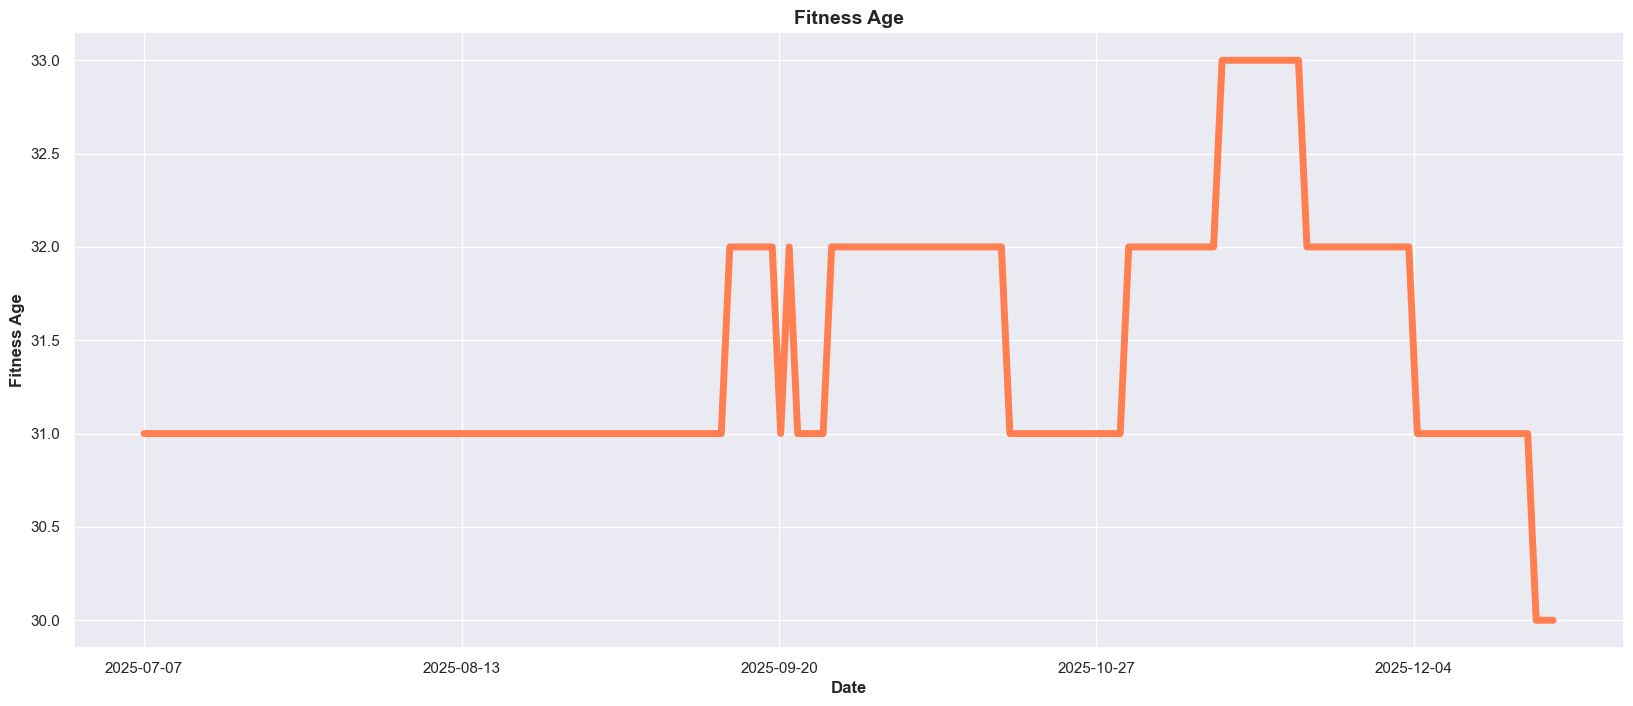

In [57]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Fitness Age'], color=MAIN_COLOR, linewidth=5)
plt.title('Fitness Age', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Fitness Age', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

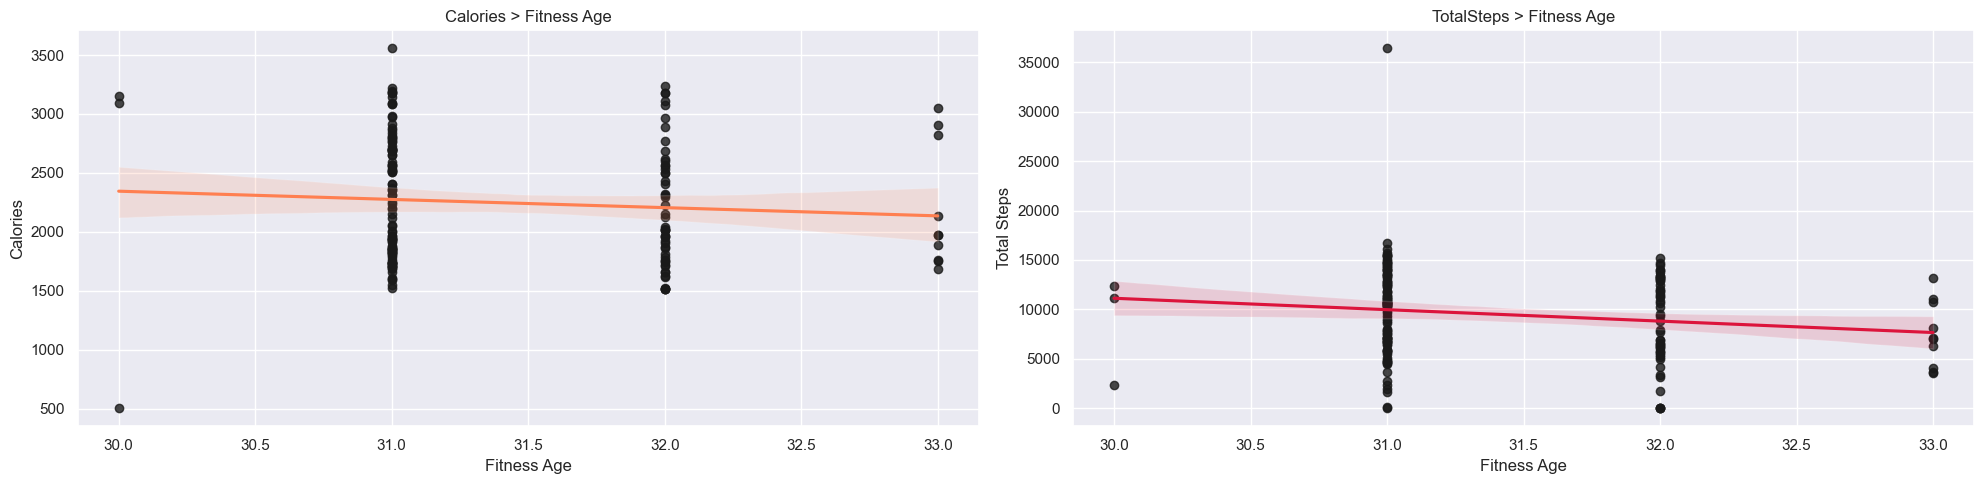

In [58]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

sns.regplot(x='Fitness Age',
            y='Calories',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': MAIN_COLOR},
            ax=ax1
            )
ax1.set_title('Calories > Fitness Age')

sns.regplot(x='Fitness Age',
            y='Total Steps',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            ax=ax2
            )
ax2.set_title('TotalSteps > Fitness Age')

plt.tight_layout()
plt.show()

## Total Calories Burned

In [59]:
df_viz.loc[:, 'rolling avg'] = df_viz['Calories'].rolling(window=7).mean()

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/1764548599.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_viz.loc[:, 'rolling avg'] = df_viz['Calories'].rolling(window=7).mean()


matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


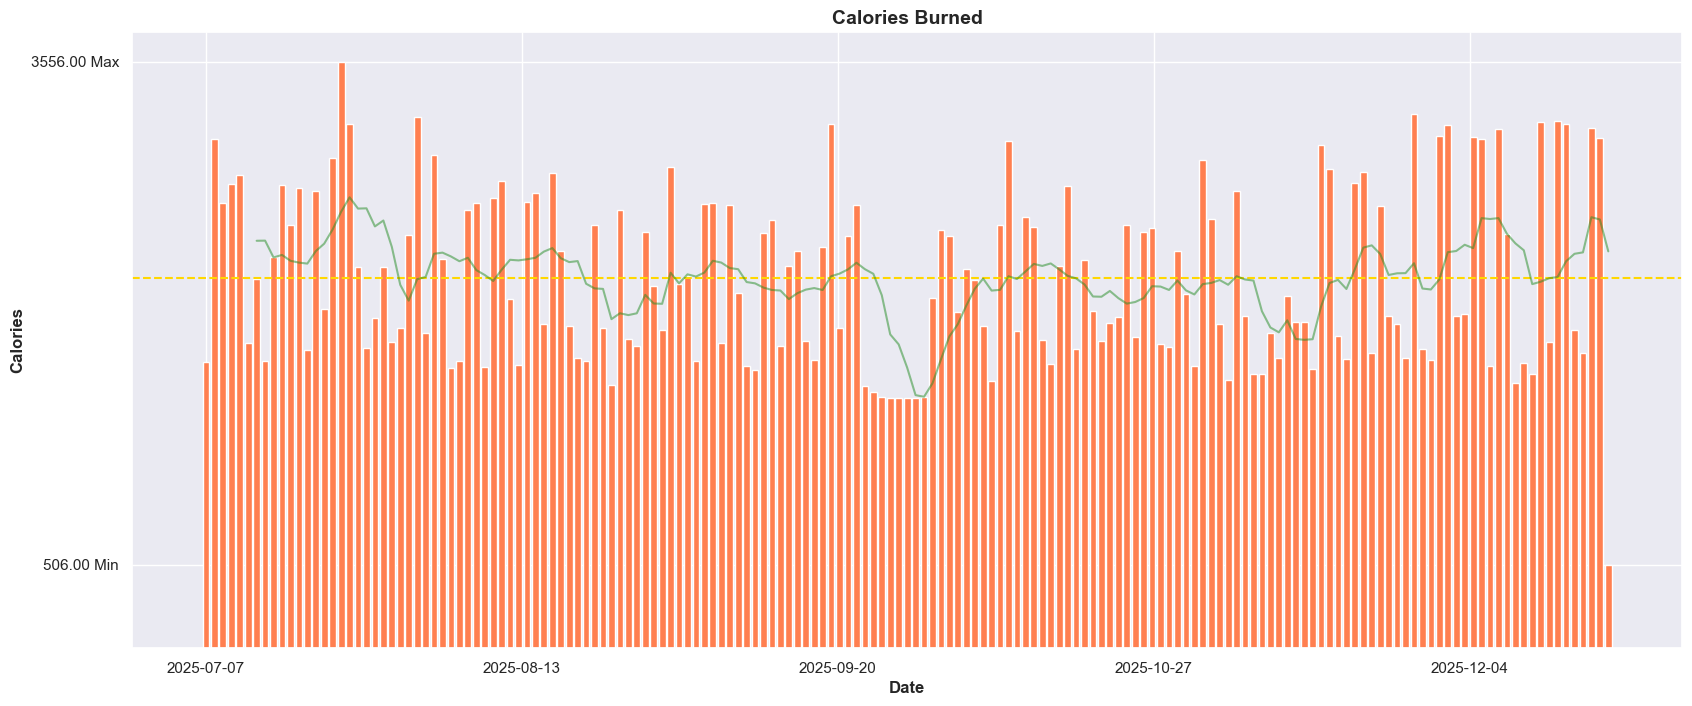

In [60]:
plt.figure(figsize=[20,8])
plt.bar(df_viz['Date'], df_viz['Calories'], color=MAIN_COLOR)
plt.axhline(y=df_viz['Calories'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Kilocalories {df_viz["Calories"].mean():.2f}')
plt.plot(df_viz['Date'], df_viz['rolling avg'], color=POSITIVE_REF_COLOR, alpha=0.5)
y_min = df_viz['Calories'].min()
y_max = df_viz['Calories'].max()
plt.yticks([y_min, y_max], [f'{y_min:.2f} Min', f'{y_max:.2f} Max'])
plt.title('Calories Burned', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Calories', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(abs(TIME_RANGE/ TIME_STEP)))
plt.show()

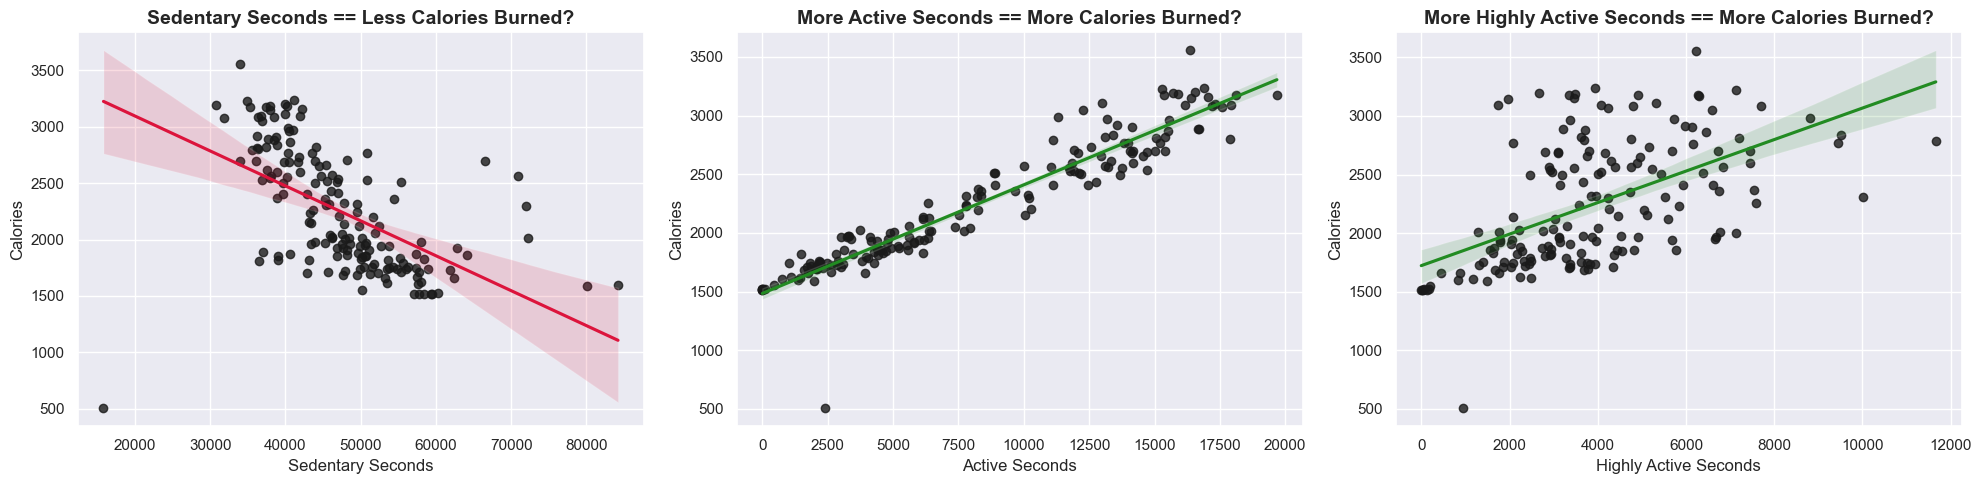

In [61]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

sns.regplot(x='Sedentary Seconds',
            y='Calories',
            data=df_viz,
            # color='grey',
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            ax=ax1
            )
ax1.set_title('Sedentary Seconds == Less Calories Burned?', fontweight='bold', fontsize=14)

sns.regplot(x='Active Seconds',
            y='Calories',
            data=df_viz,
            # color='grey',
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            ax=ax2
            )
ax2.set_title('More Active Seconds == More Calories Burned?', fontweight='bold', fontsize=14)

sns.regplot(x='Highly Active Seconds',
            y='Calories',
            data=df_viz,
            # color='grey',
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            ax=ax3
            )
ax3.set_title('More Highly Active Seconds == More Calories Burned?', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

## Heart Rate Data

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

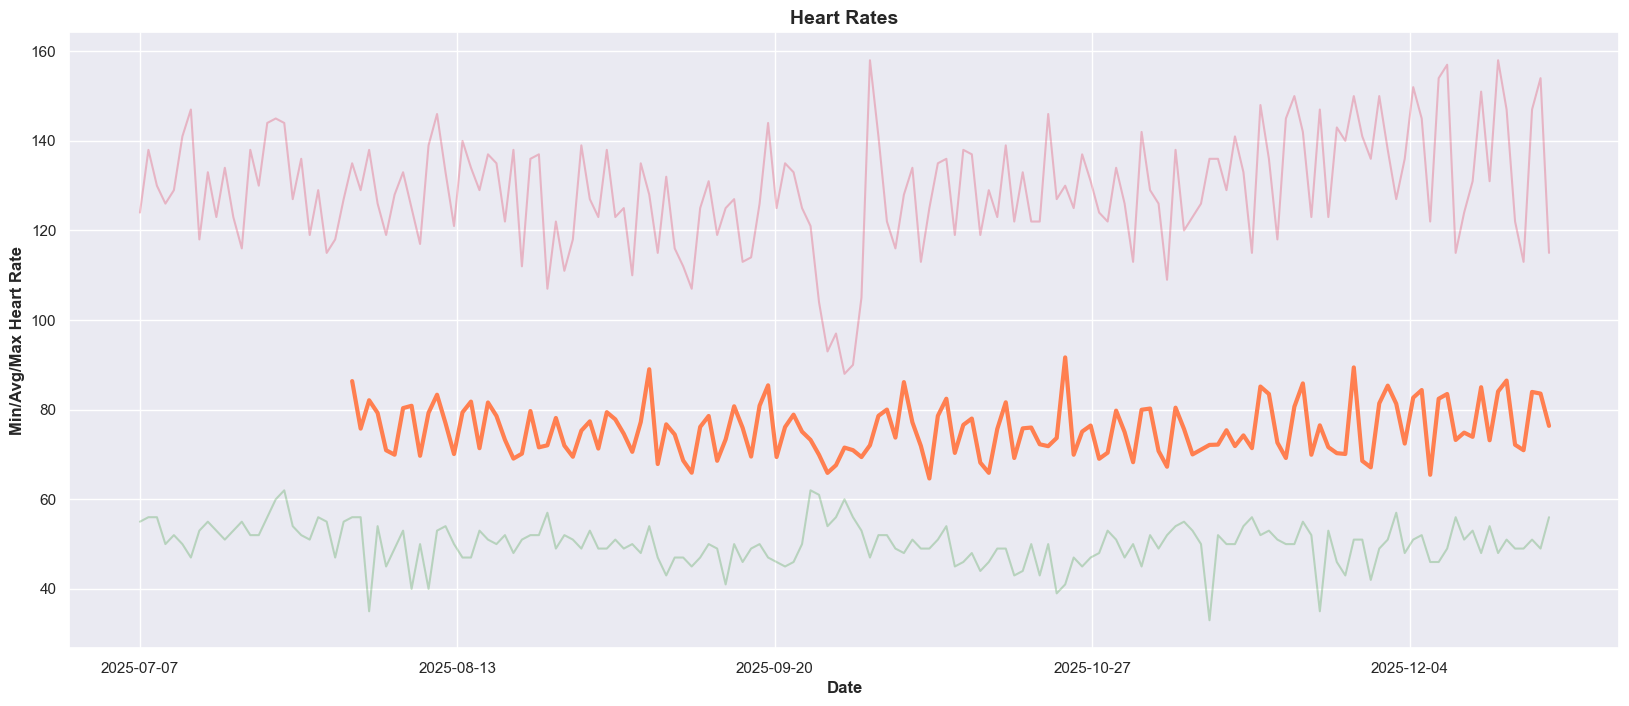

In [62]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Max Heart Rate'], color=NEGATIVE_REF_COLOR, alpha=.25)
plt.plot(df_viz['Date'], df_viz['Min Heart Rate'], color=POSITIVE_REF_COLOR, alpha=.25)
plt.plot(df_viz['Date'], df_viz['Average Heart Rate'], color=MAIN_COLOR, linewidth=3)
plt.title('Heart Rates', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Min/Avg/Max Heart Rate', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

## Total Steps Taken
That spike is from a hike in the Columbia River Gorge

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


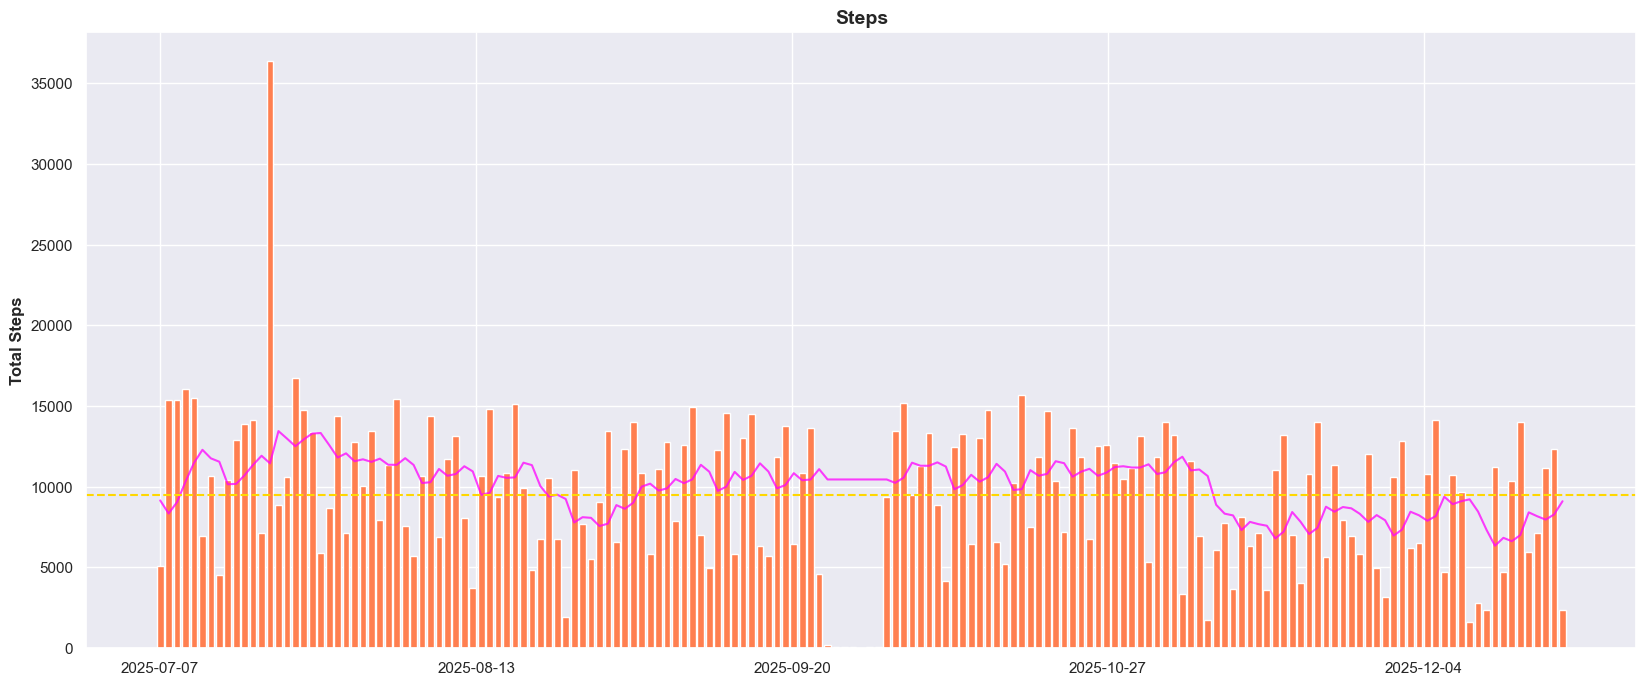

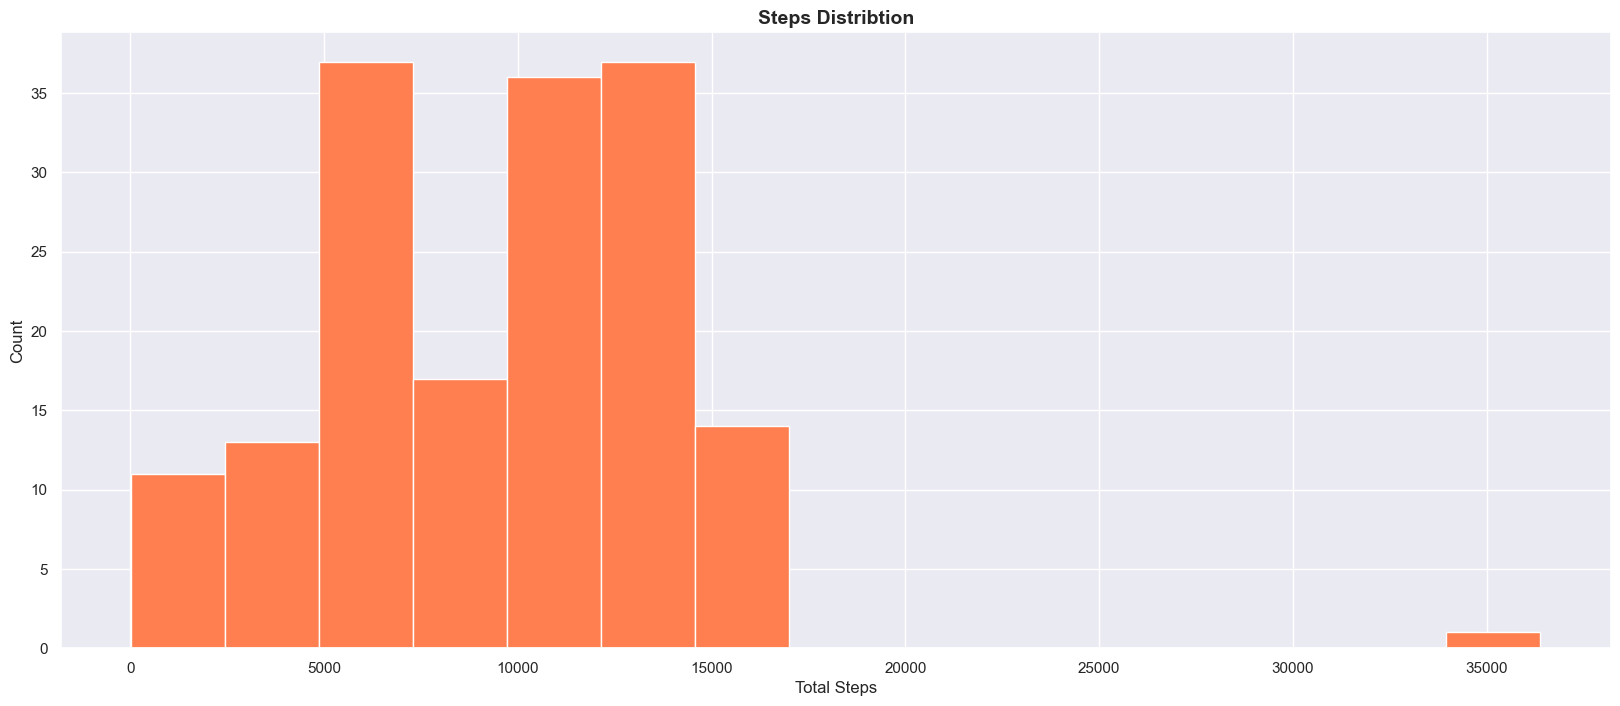

In [63]:
plt.figure(figsize=[20,8])
plt.bar(df_viz['Date'], df_viz['Total Steps'], color=MAIN_COLOR)
plt.plot(df_viz['Date'], df_viz['Daily Step Goal'], color='magenta', alpha=.75)
plt.axhline(y=df_viz['Total Steps'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Total Steps"].mean():.2f}')
y_min = df_viz['Total Steps'].min()
y_max = df_viz['Total Steps'].max()
plt.ylabel('Total Steps', fontweight='bold')
plt.title('Steps', fontweight='bold', fontsize=14)
ax1 = plt.gca()
ax1.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))

plt.show()
plt.figure(figsize=[20,8])
plt.hist(df_viz['Total Steps'], bins=15, color=MAIN_COLOR)
plt.title('Steps Distribtion', fontsize=14, weight='bold')
plt.xlabel('Total Steps')
plt.ylabel('Count')

plt.show()

## Total Miles Walked


In [64]:
df_viz_tmp = df_viz[['Date', 'Total Distance Meters']]
df_viz_tmp.loc[:, 'Total Distance Meters'] = df_viz_tmp['Total Distance Meters'] / 1609

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


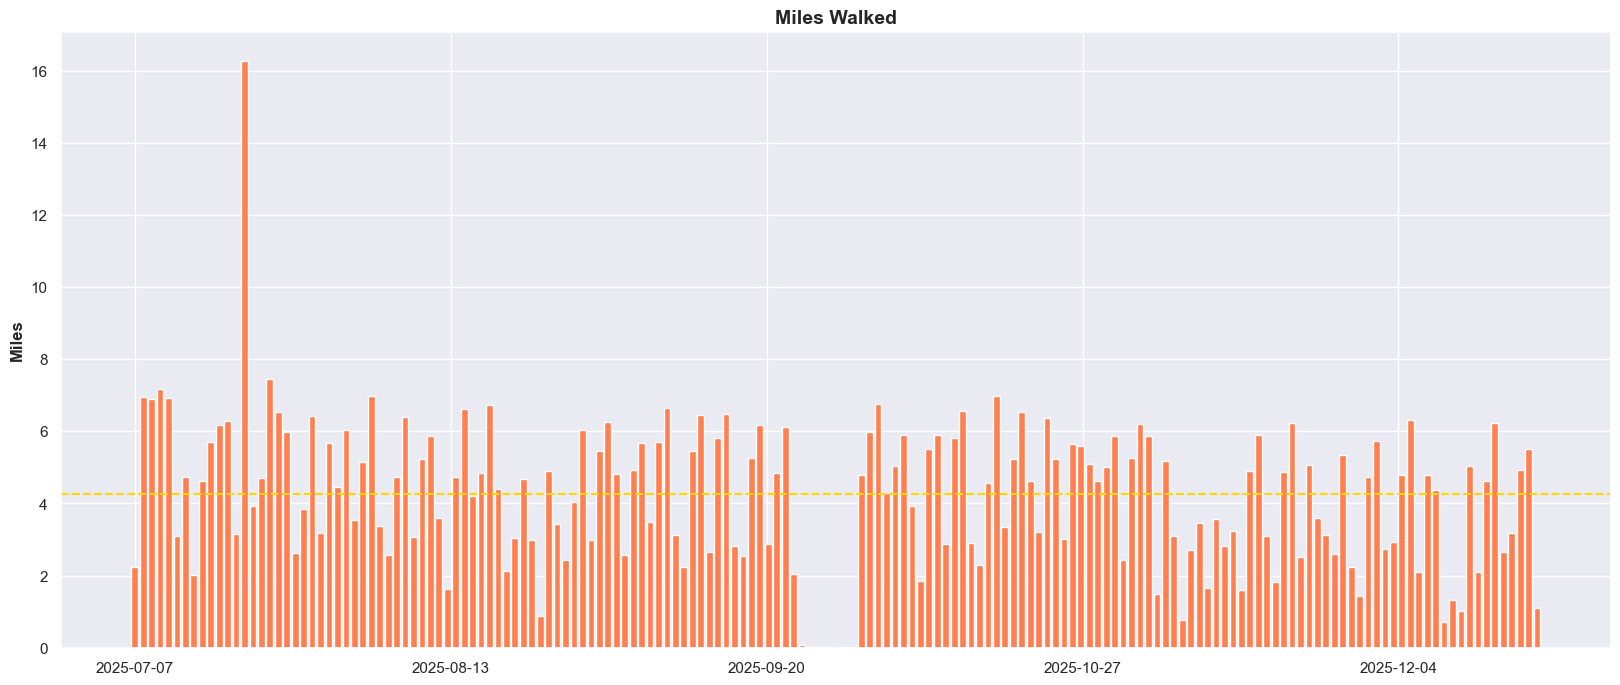

Text(0, 0.5, 'Count')

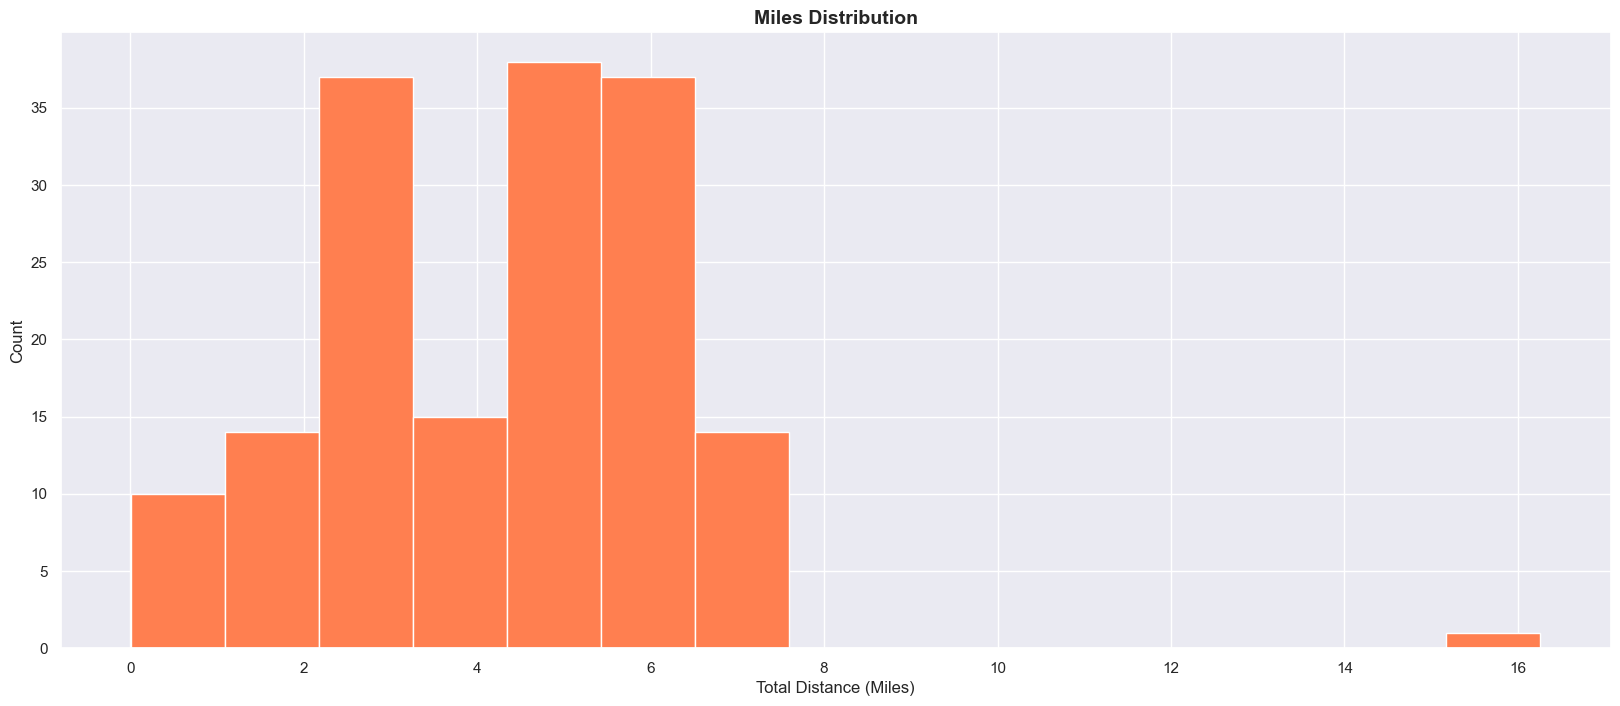

In [65]:
plt.figure(figsize=[20,8])
plt.bar(df_viz_tmp['Date'], df_viz_tmp['Total Distance Meters'], color=MAIN_COLOR)
plt.axhline(y=df_viz_tmp['Total Distance Meters'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz_tmp["Total Distance Meters"].mean():.2f}')
y_min = df_viz_tmp['Total Distance Meters'].min()
y_max = df_viz_tmp['Total Distance Meters'].max()
plt.title('Miles Walked', fontweight='bold', fontsize=14)
plt.ylabel('Miles', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

plt.show()
plt.figure(figsize=[20,8])
plt.hist(df_viz_tmp['Total Distance Meters'], bins=15, color=MAIN_COLOR)
plt.title('Miles Distribution', fontsize=14, weight='bold')
plt.xlabel('Total Distance (Miles)')
plt.ylabel('Count')

## Sleep Duration

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


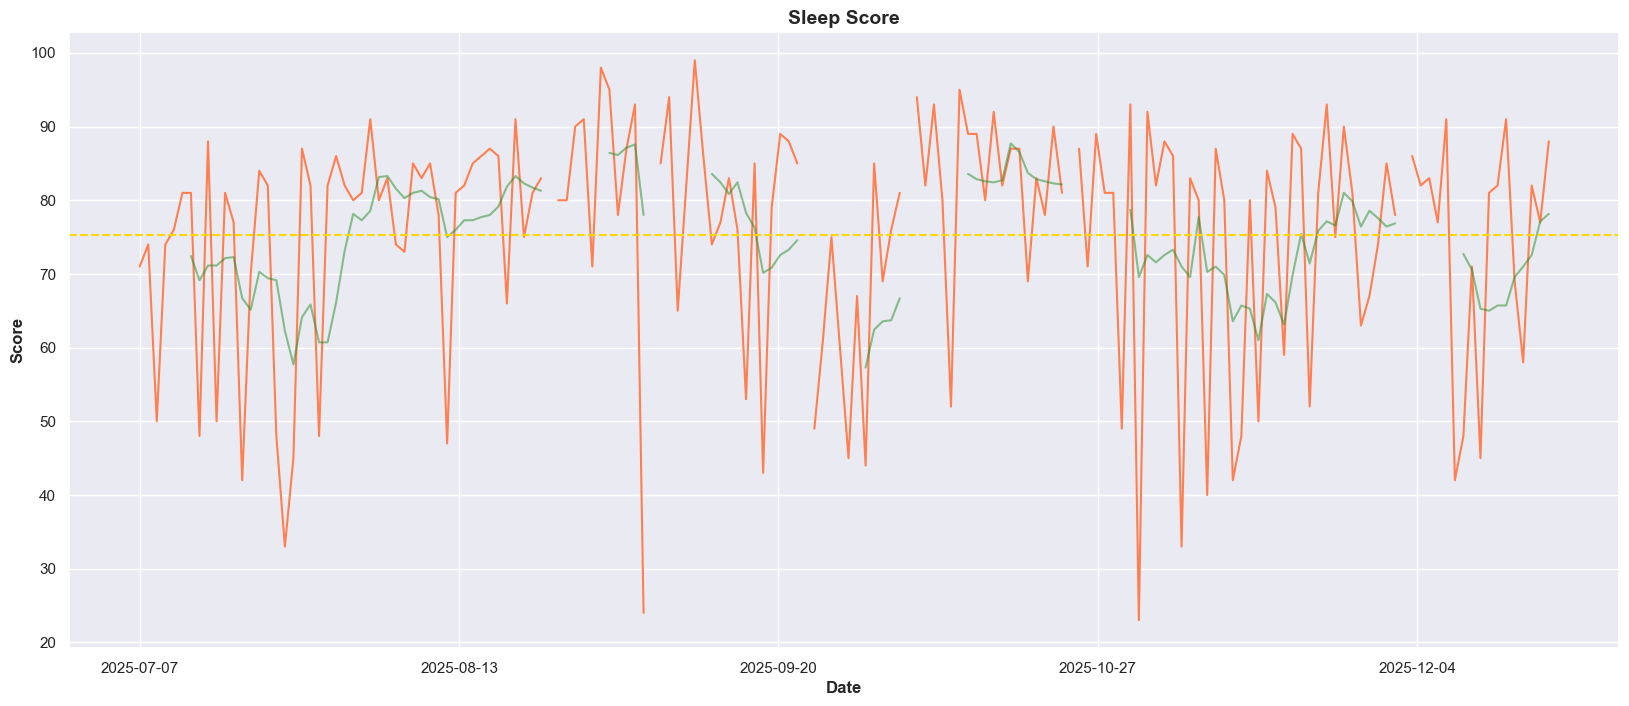

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

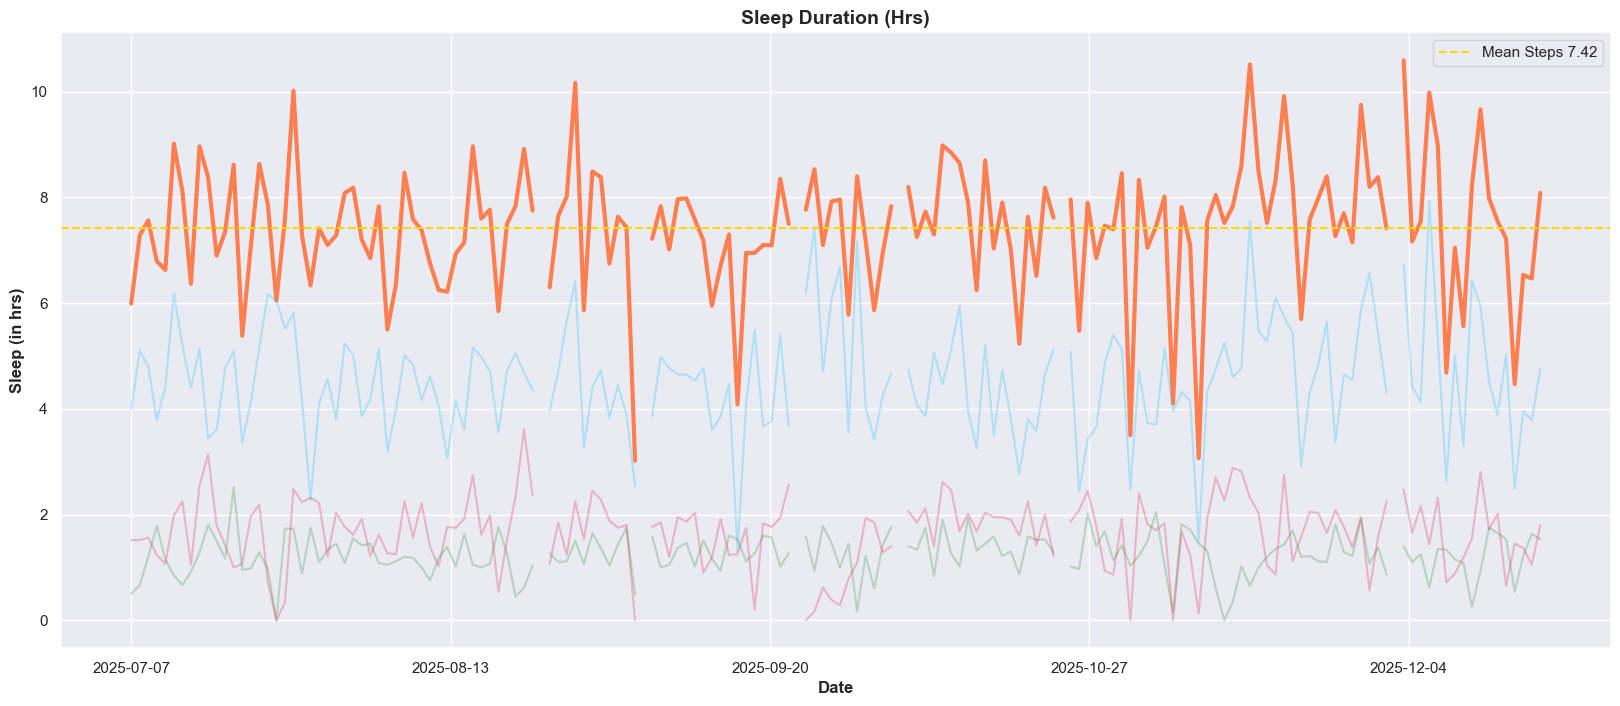

In [66]:
df_viz.loc[:, 'rolling avg'] = df_viz['Sleep Score'].rolling(window=7).mean()
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Sleep Score'], color=MAIN_COLOR)
plt.plot(df_viz['Date'], df_viz['rolling avg'], color=POSITIVE_REF_COLOR, alpha=.5)
plt.axhline(y=df_viz['Sleep Score'].mean(), linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Sleep Score"].mean():.2f}')
plt.title('Sleep Score', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Sleep Time Seconds'] / 3600, color=MAIN_COLOR, linewidth=3)
plt.plot(df_viz['Date'], df_viz['Light Sleep Seconds'] / 3600, color='deepskyblue', alpha=.25)
plt.plot(df_viz['Date'], df_viz['Deep Sleep Seconds'] / 3600, color='forestgreen', alpha=.25)
plt.plot(df_viz['Date'], df_viz['Rem Sleep Seconds'] / 3600, color='crimson', alpha=.25)
plt.axhline(y=df_viz['Sleep Time Seconds'].mean() / 3600, linestyle='dashed', color=REF_COLOR, label=f'Mean Steps {df_viz["Sleep Time Seconds"].mean() / 3600:.2f}')
plt.legend()
plt.title('Sleep Duration (Hrs)', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Sleep (in hrs)', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

## Sleep Score

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


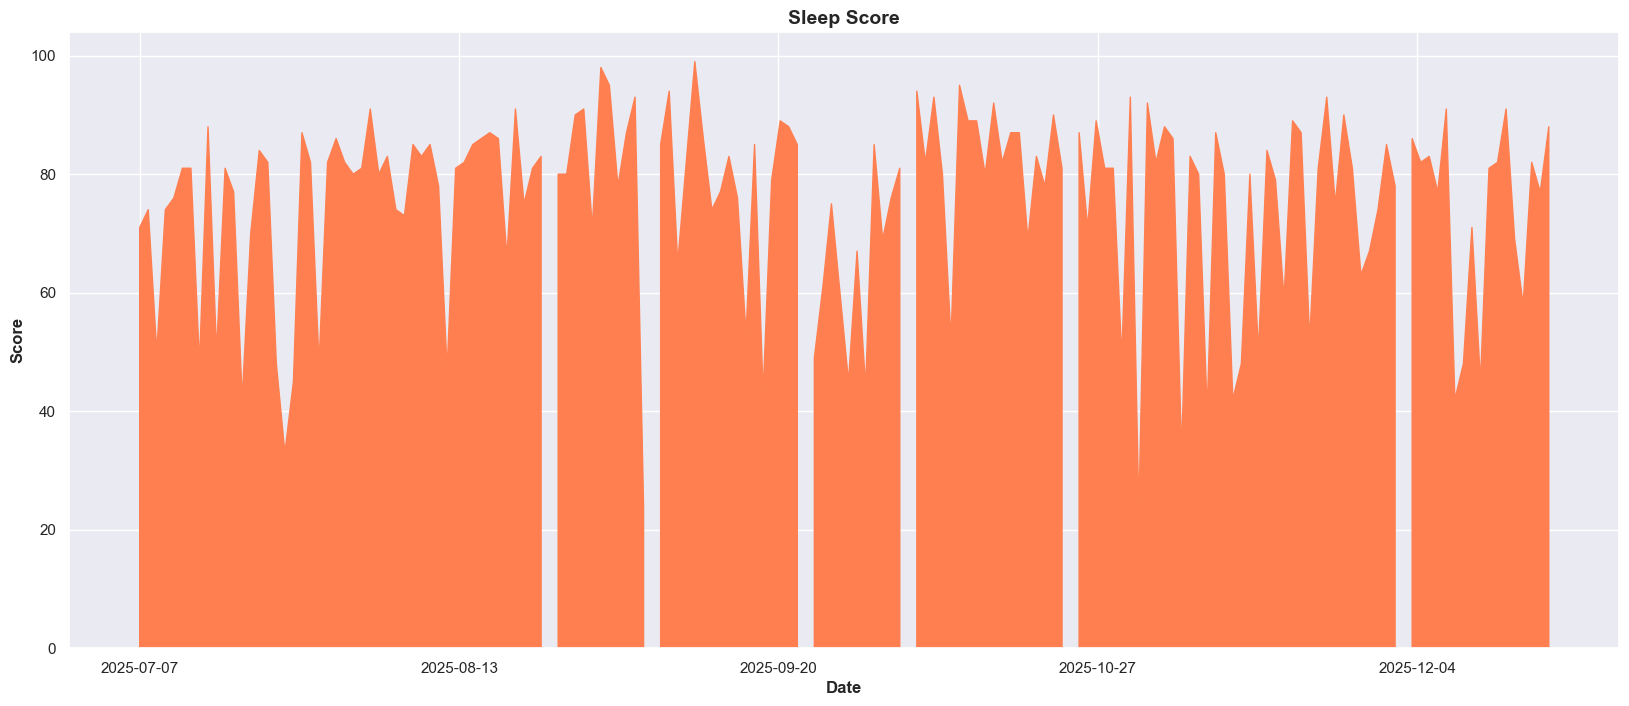

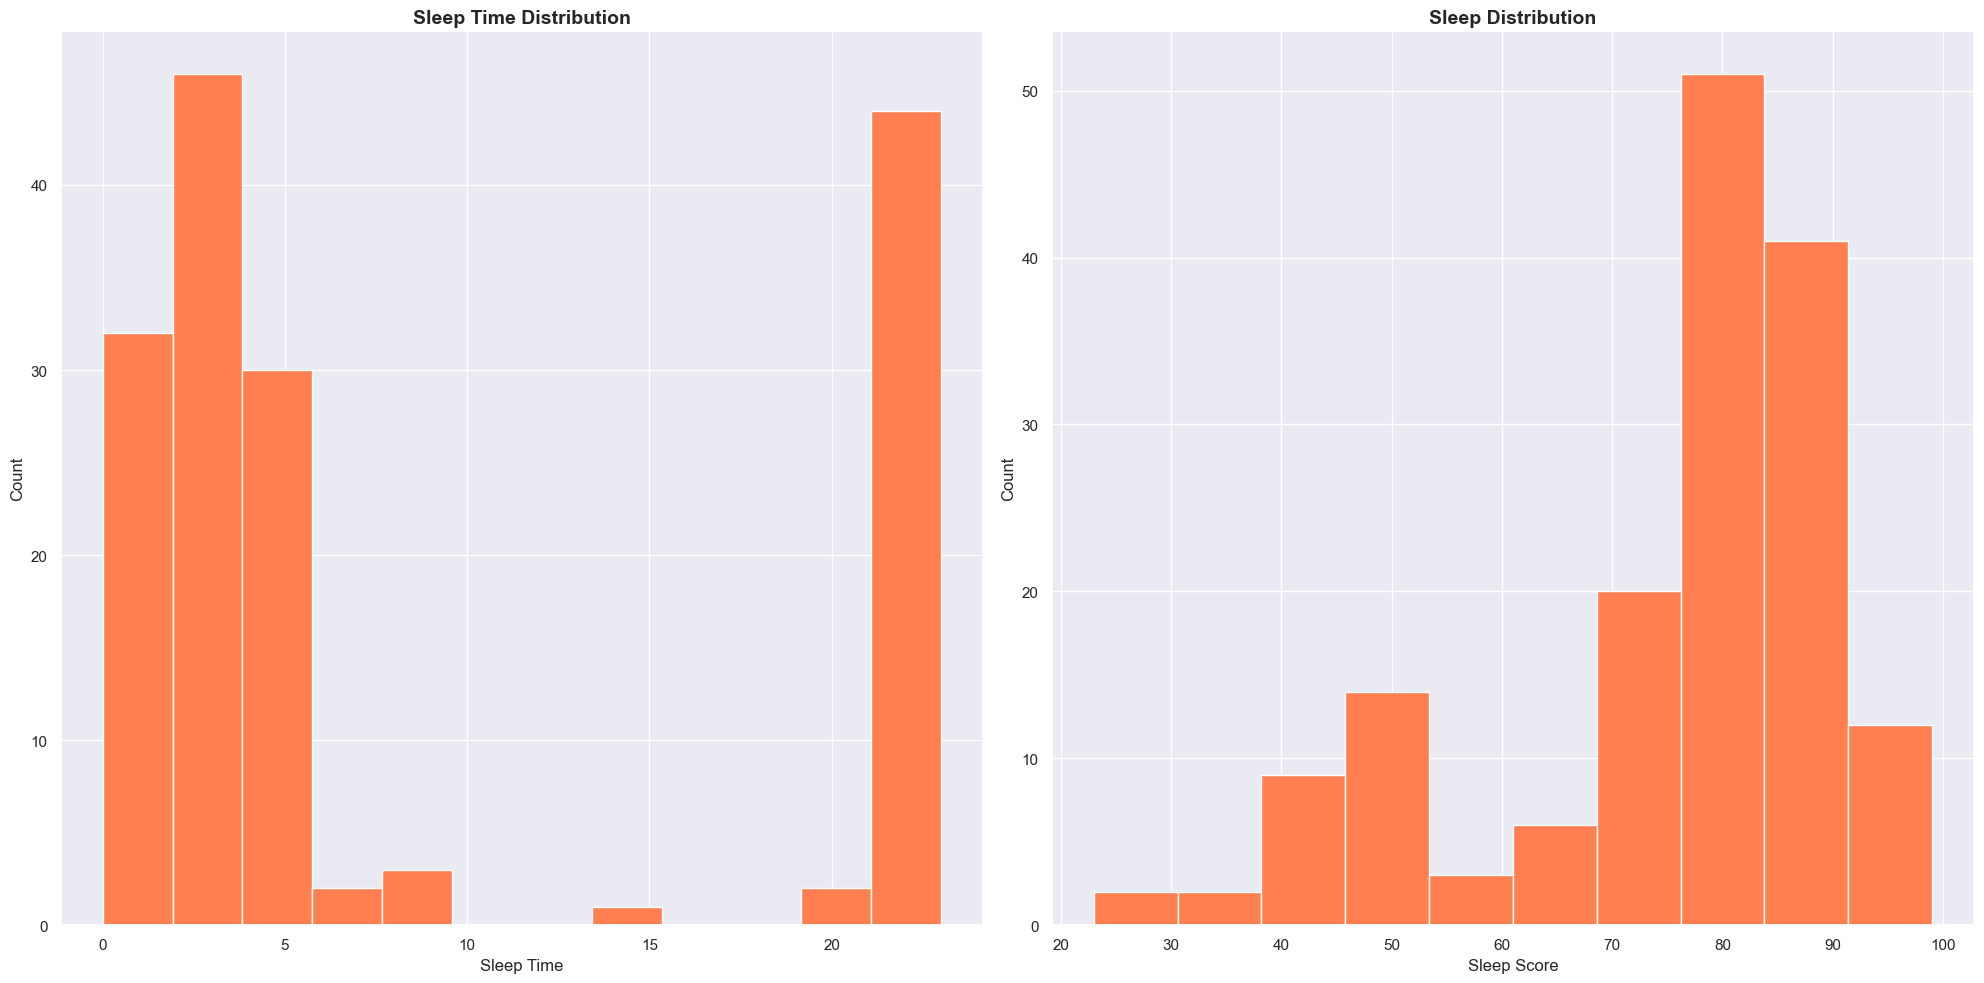

In [105]:
plt.figure(figsize=[20,8])
plt.stackplot(df_viz['Date'], df_viz['Sleep Score'], color=MAIN_COLOR)
plt.title('Sleep Score', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 10))

ax1.hist(df_viz['Sleep Start Timestamp Local'].dt.hour, bins=12, color=MAIN_COLOR)
ax1.set_title('Sleep Time Distribution', fontsize=14, weight='bold')
ax1.set_xlabel('Sleep Time')
ax1.set_ylabel('Count')

## What my aggregated sleep scores are
ax2.hist(df_viz['Sleep Score'], bins=10, color=MAIN_COLOR)
ax2.set_title('Sleep Distribution', fontsize=14, weight='bold')
ax2.set_xlabel('Sleep Score')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

## What my aggregated sleep scores are

In [68]:
# TODO: Sleep times start and end
df_viz['Sleep Start Timestamp Local'] = pd.to_datetime(df_viz['Sleep Start Timestamp Local'])

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/225023498.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_viz['Sleep Start Timestamp Local'] = pd.to_datetime(df_viz['Sleep Start Timestamp Local'])


## Better Sleep?

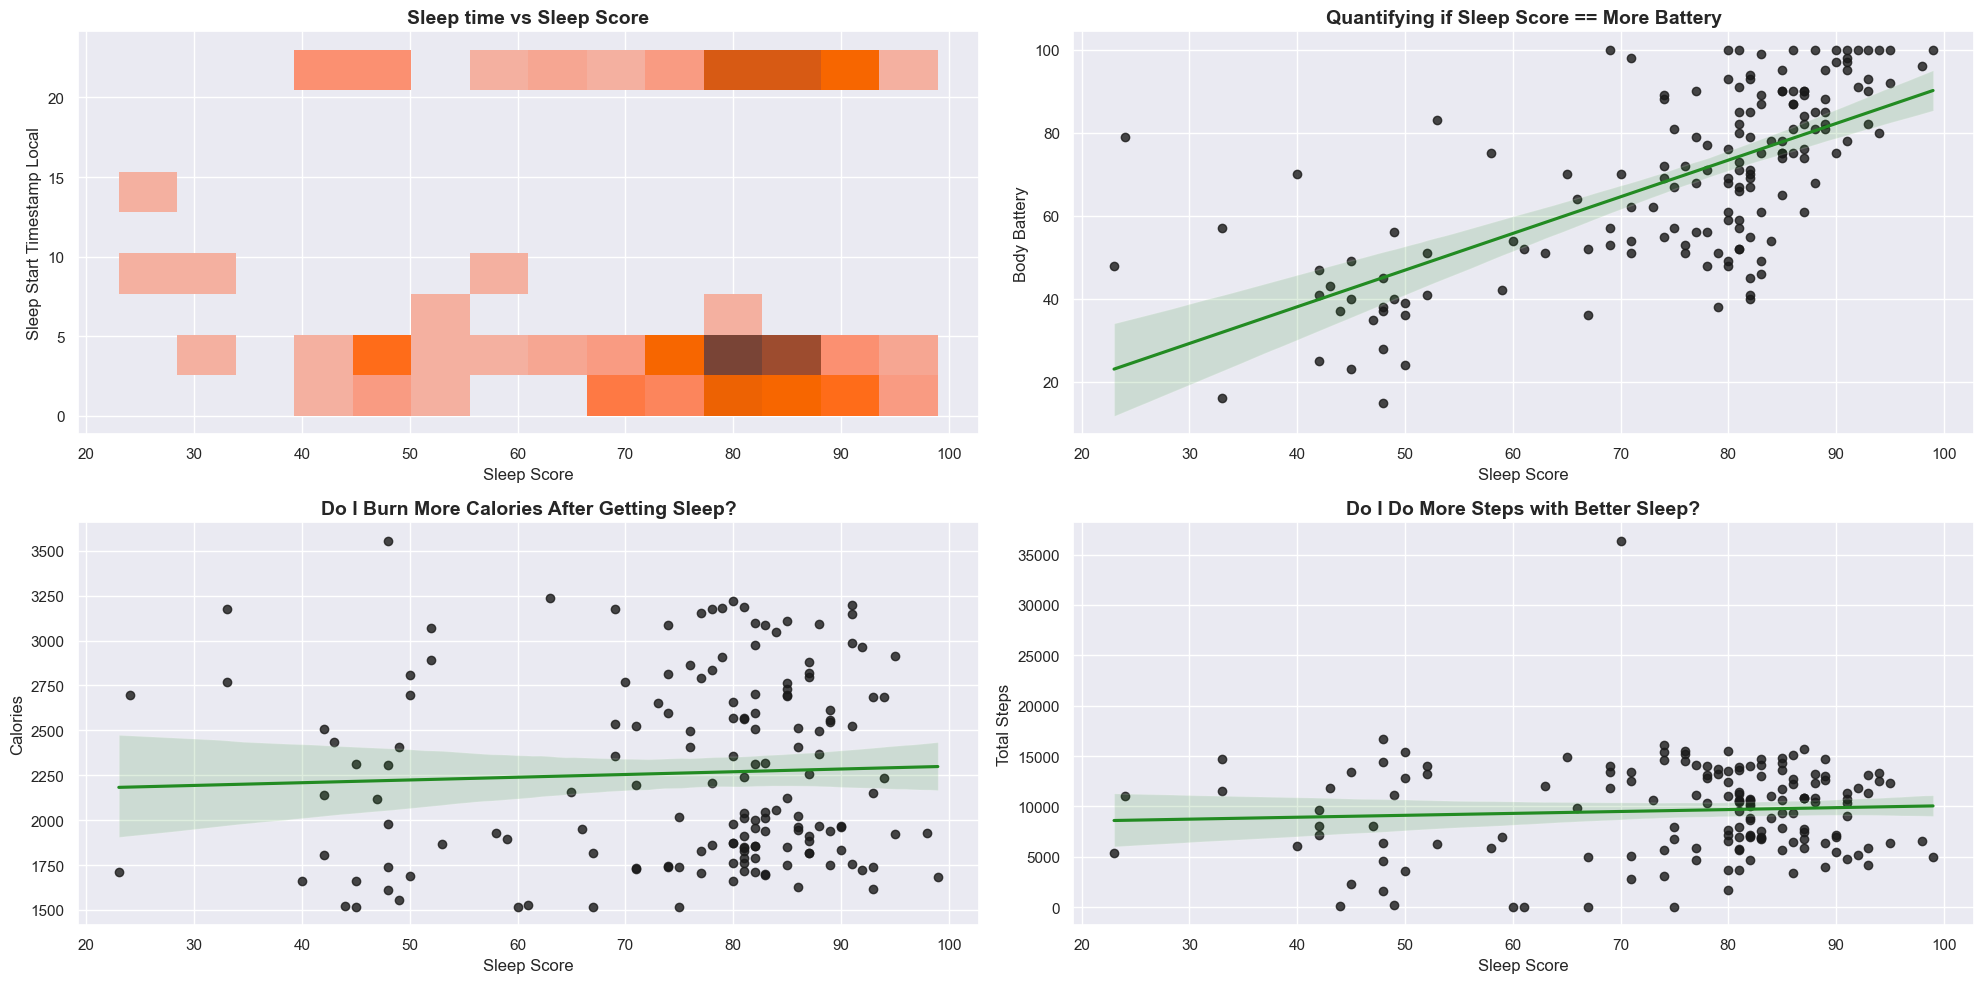

In [108]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

sns.histplot(x='Sleep Score',
            y=df_viz['Sleep Start Timestamp Local'].dt.hour,
            data=df_viz,
            ax=ax1,
             color=MAIN_COLOR,
            )
ax1.set_title('Sleep time vs Sleep Score', fontweight='bold', fontsize=14)

sns.regplot(x='Sleep Score',
            y='Body Battery',
            data=df_viz,
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            ax=ax2
            )
ax2.set_title('Quantifying if Sleep Score == More Battery', fontweight='bold', fontsize=14)

sns.regplot(x='Sleep Score',
            y='Calories',
            data=df_viz,
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            ax=ax3
            )
ax3.set_title('Do I Burn More Calories After Getting Sleep?', fontweight='bold', fontsize=14)

sns.regplot(x='Sleep Score',
            y='Total Steps',
            data=df_viz,
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            ax=ax4
            )
ax4.set_title('Do I Do More Steps with Better Sleep?', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

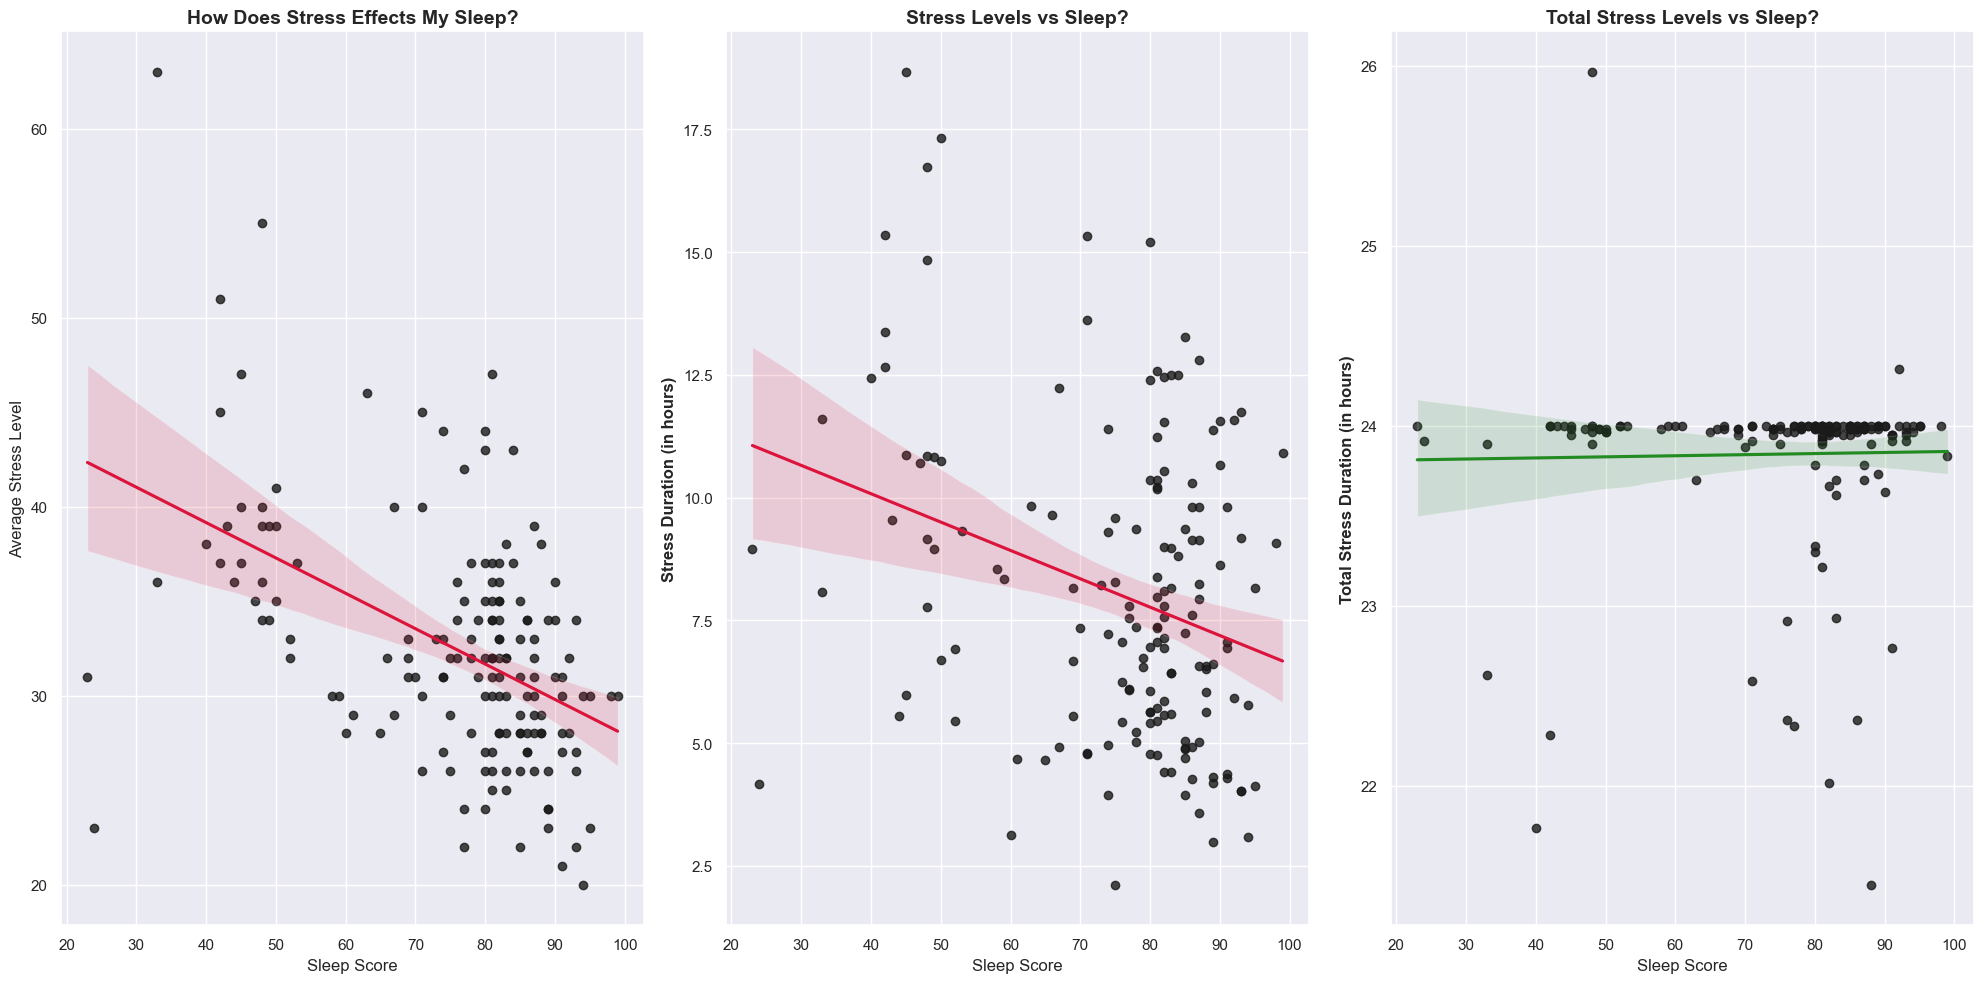

In [71]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20, 10))

sns.regplot(x='Sleep Score',
            y='Average Stress Level',
            data=df_viz,
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            ax=ax1
            )
ax1.set_title('How Does Stress Effects My Sleep?', fontweight='bold', fontsize=14)

sns.regplot(x='Sleep Score',
            y='Stress Seconds',
            data=df_viz_tmp,
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            ax=ax2
            )
ax2.set_title('Stress Levels vs Sleep?', fontweight='bold', fontsize=14)
ax2.set_ylabel('Stress Duration (in hours)', fontweight='bold')

sns.regplot(x='Sleep Score',
            y='Total Stress Seconds',
            data=df_viz_tmp,
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            ax=ax3
            )
ax3.set_title('Total Stress Levels vs Sleep?', fontweight='bold', fontsize=14)
ax3.set_ylabel('Total Stress Duration (in hours)', fontweight='bold')

plt.tight_layout()
plt.show()

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/845478591.py:14: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.stripplot(x='Sleep Quality',
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/845478591.py:26: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:coral'` for the same effect.

  sns.stripplot(x='Sleep Quality',
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/845478591.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[13.61666667  7.21666667  6.7         4.96666667  5.43333333  5.71666667
 11.23333333 10.85        6.56666667 10.75        5.45        7.8
 12.65        7.35       12.5         5.85        9.15       11.6
 10.86666667  9.81666667  4.4         7.76666667 11.53333

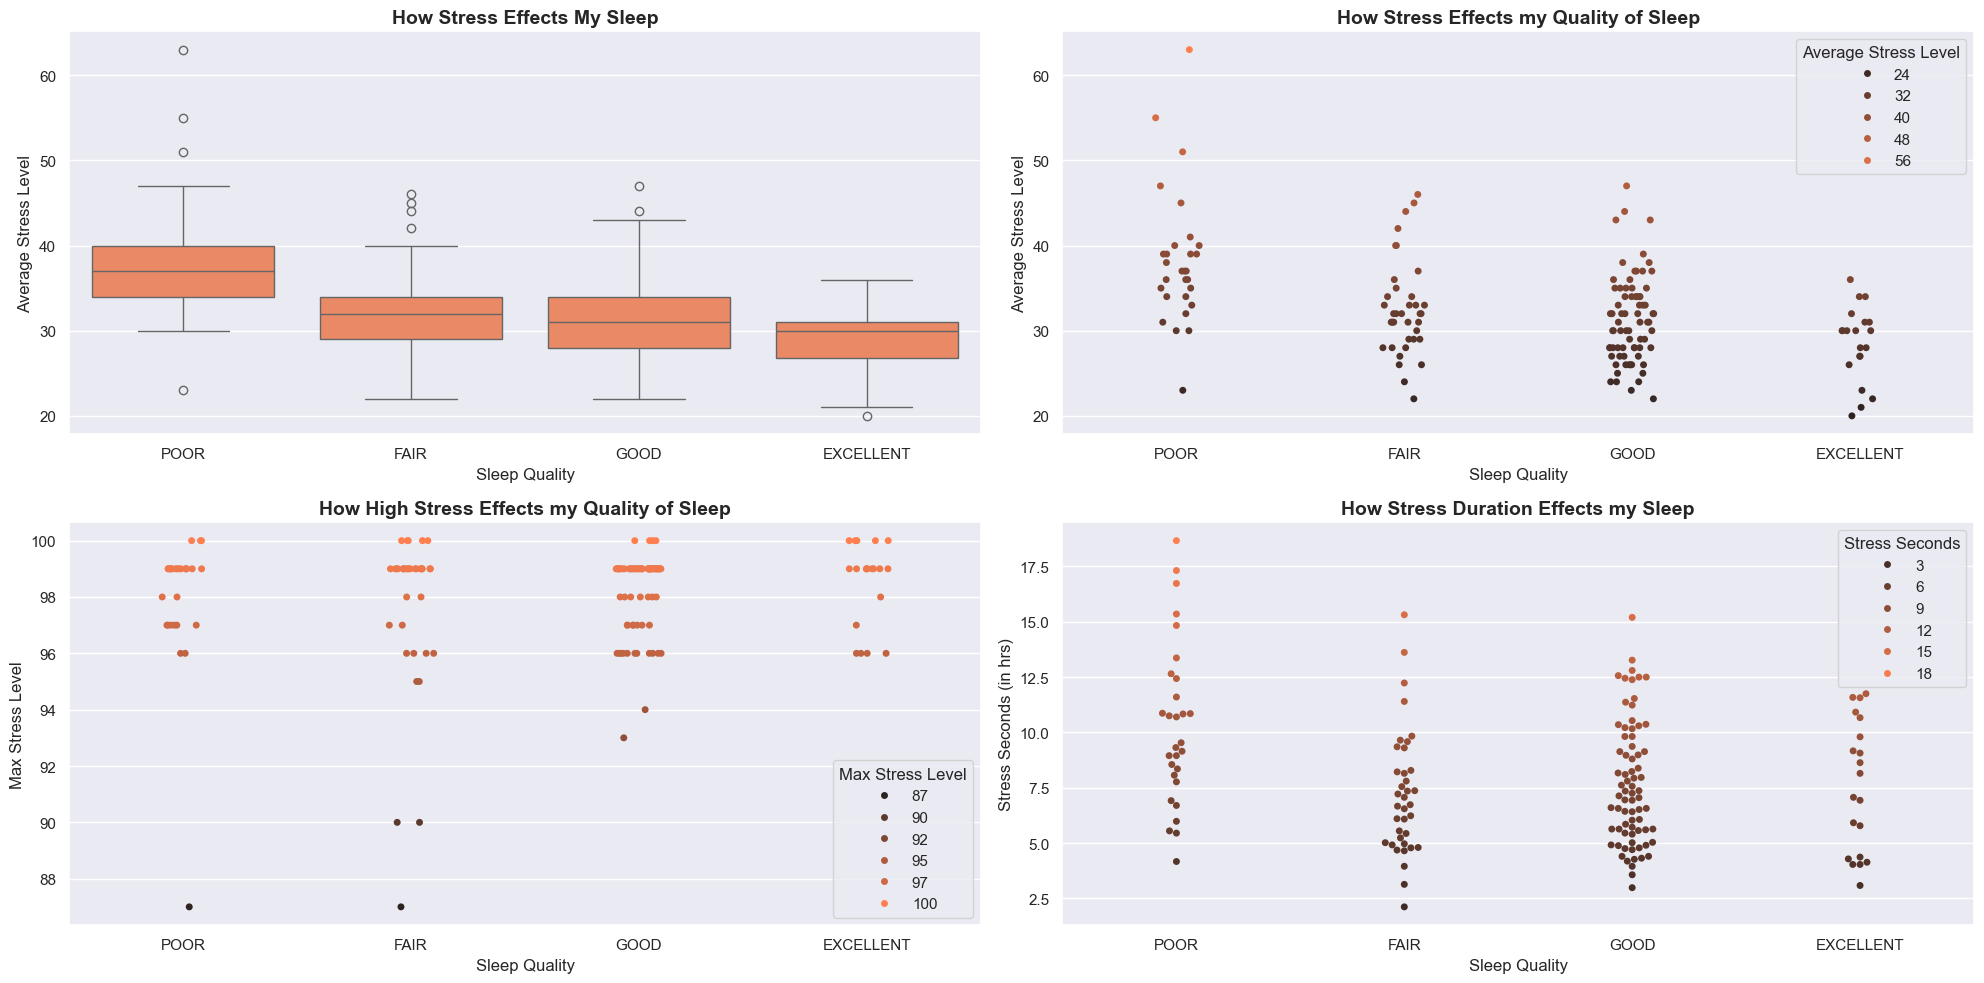

In [72]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

sns.boxplot(x='Sleep Quality',
            y='Average Stress Level',
            data=df_viz,
            color=MAIN_COLOR,
            order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'],
            ax=ax1,
            )
ax1.set_ylabel('Average Stress Level')
ax1.set_xlabel('Sleep Quality')
ax1.set_title('How Stress Effects My Sleep', fontweight='bold', fontsize=14)

sns.stripplot(x='Sleep Quality',
              y='Average Stress Level',
              data=df_viz,
              color=MAIN_COLOR,
              hue='Average Stress Level',
              order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'],
              ax=ax2,
            )
ax2.set_ylabel('Average Stress Level')
ax2.set_xlabel('Sleep Quality')
ax2.set_title('How Stress Effects my Quality of Sleep', fontweight='bold', fontsize=14)

sns.stripplot(x='Sleep Quality',
              y='Max Stress Level',
              data=df_viz,
              color=MAIN_COLOR,
              hue='Max Stress Level',
              order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'],
              ax=ax3,
            )
ax3.set_ylabel('Max Stress Level')
ax3.set_xlabel('Sleep Quality')
ax3.set_title('How High Stress Effects my Quality of Sleep', fontweight='bold', fontsize=14)


df_viz_tmp = df_viz[['Stress Seconds', 'Sleep Quality']]
df_viz_tmp.loc[:, 'Stress Seconds'] = df_viz_tmp['Stress Seconds'] / 3600
sns.swarmplot(x='Sleep Quality',
              y='Stress Seconds',
              data=df_viz_tmp,
              hue='Stress Seconds',
              color=MAIN_COLOR,
              order=['POOR', 'FAIR', 'GOOD', 'EXCELLENT'],
              ax=ax4)
ax4.set_ylabel('Stress Seconds (in hrs)')
ax4.set_title('How Stress Duration Effects my Sleep', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()



## Intensity

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these stri

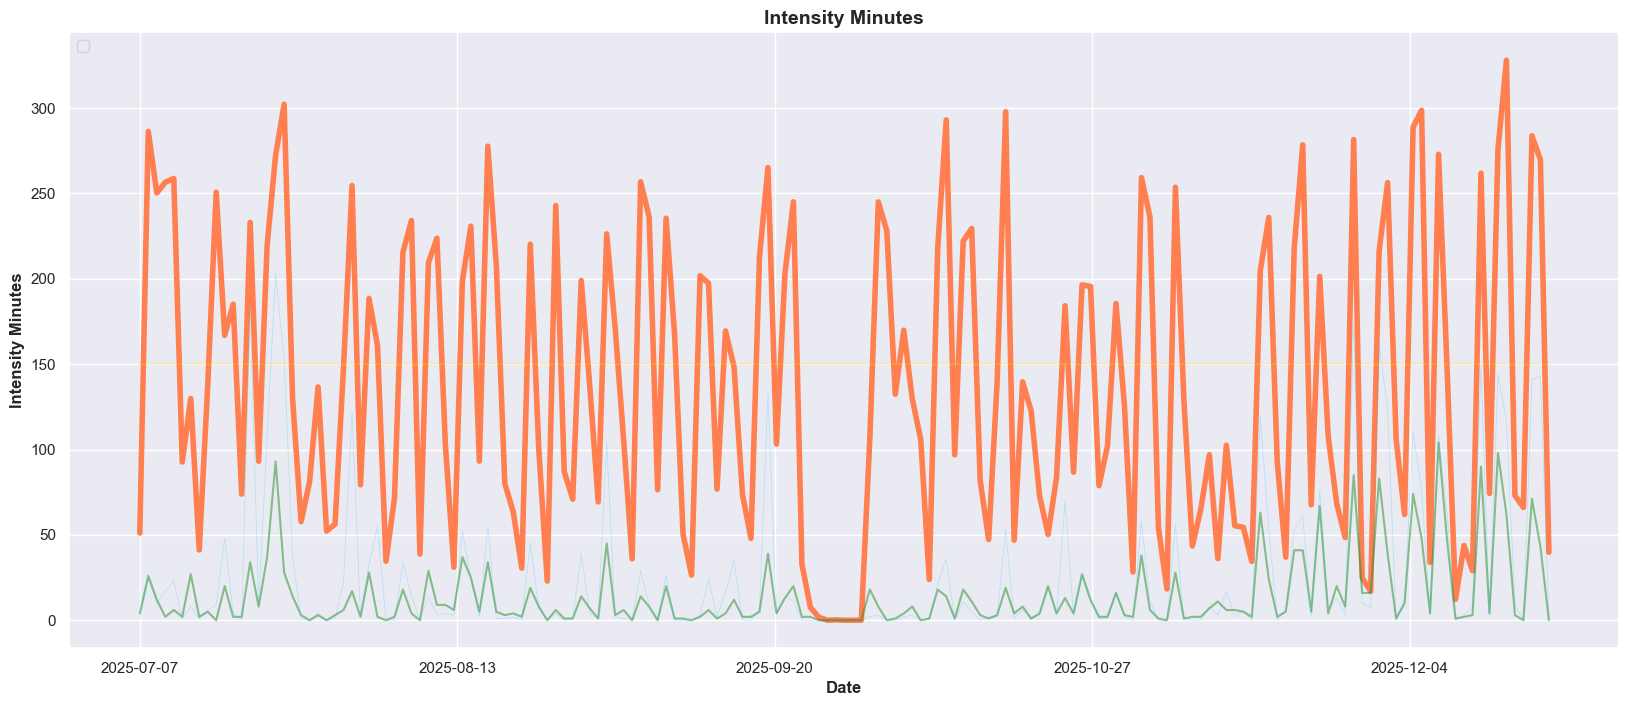

In [73]:
plt.figure(figsize=[20,8])
plt.plot(df_viz['Date'], df_viz['Active Seconds'] / 60, color=MAIN_COLOR, linewidth=4)
plt.plot(df_viz['Date'], df_viz['Vigorous Intensity Minutes'], color=POSITIVE_REF_COLOR, alpha=.5)
plt.plot(df_viz['Date'], df_viz['Moderate Intensity Minutes'], color='deepskyblue', alpha=.25, linewidth=.5)
plt.plot(df_viz['Date'], df_viz['Intensity Minutes Goal'], color=REF_COLOR, alpha=.25)
plt.legend(loc='upper left')
plt.title('Intensity Minutes', fontweight='bold', fontsize=14)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Intensity Minutes', fontweight='bold')
ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

## Stress Data
The more stressed I am, the worse sleep I get

matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category: INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


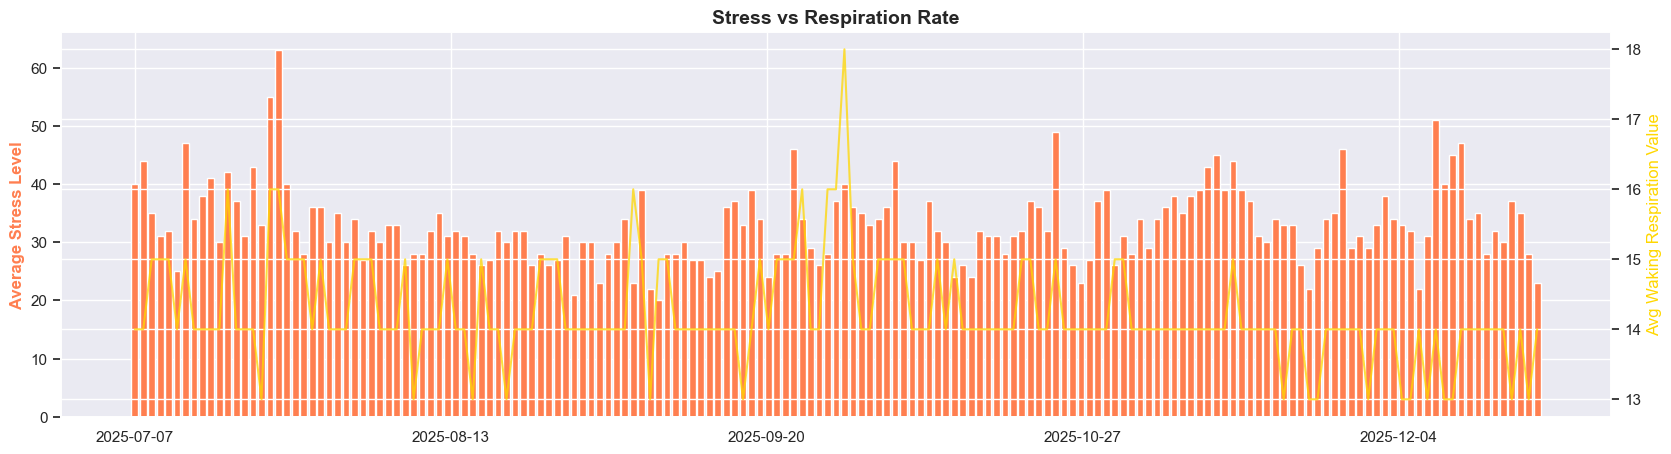

In [90]:

fix, ax1 = plt.subplots(figsize=[20,5])

ax1.bar(df_viz['Date'], df_viz['Average Stress Level'], color=MAIN_COLOR)
ax1.set_ylabel('Average Stress Level', fontweight='bold', color=MAIN_COLOR)

ax2 = ax1.twinx()

ax2.plot(df_viz['Date'], df_viz['Avg Waking Respiration Value'], color=REF_COLOR, alpha=.75)
ax2.set_ylabel('Avg Waking Respiration Value', color=REF_COLOR)

plt.title('Stress vs Respiration Rate', fontweight='bold', fontsize=14)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(TIME_RANGE/ TIME_STEP))
plt.show()

## How my Body Battery effects my Stress Levels
The lower my body battery at the beginning of hte day, the more likely I am to be more stresed

Text(0.5, 1.0, 'How My Body Battery Effects my Stress Levels')

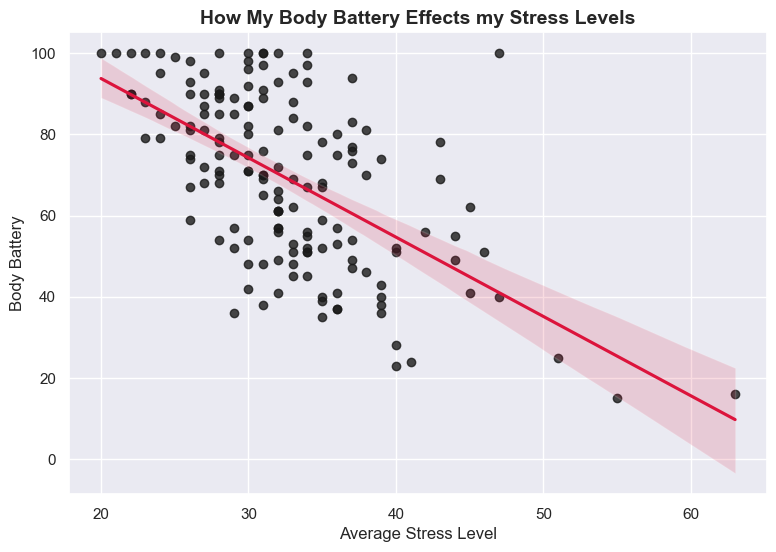

In [75]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Body Battery',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            )
plt.title('How My Body Battery Effects my Stress Levels', fontweight='bold', fontsize=14)

## My Stress Levels and Sleep

## How Does Stress Effect My Heart Rate?

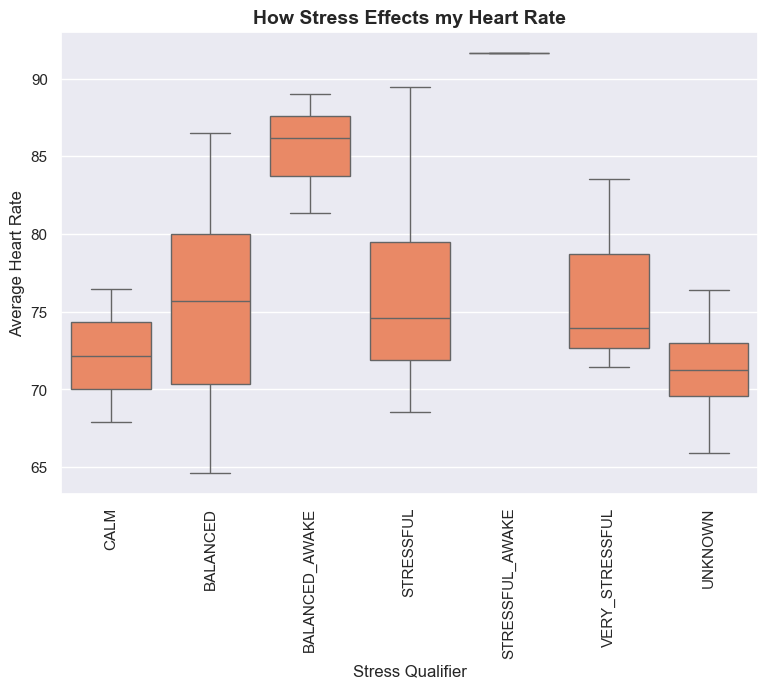

In [76]:
plt.figure(figsize=(9, 6))
sns.boxplot(df_viz,
            x='Stress Qualifier',
            y='Average Heart Rate',
            color=MAIN_COLOR,
            order=['CALM', 'BALANCED', 'BALANCED_AWAKE', 'STRESSFUL', 'STRESSFUL_AWAKE', 'VERY_STRESSFUL', 'UNKNOWN'])
plt.title('How Stress Effects my Heart Rate', fontweight='bold', fontsize=14)
plt.xticks(rotation=90)
plt.show() # Display the plot

In [77]:
df_viz_tmp = df_viz[['Stress Seconds', 'Calories']]
df_viz_tmp.loc[:, 'Stress Seconds'] = df_viz_tmp['Stress Seconds'] / 3600

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/1822918326.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[13.61666667  7.21666667  6.7         4.96666667  5.43333333  5.71666667
 11.23333333 10.85        6.56666667 10.75        5.45        7.8
 12.65        7.35       12.5         5.85        9.15       11.6
 10.86666667  9.81666667  4.4         7.76666667 11.53333333  9.13333333
  8.98333333  4.78333333  8.38333333  4.28333333  5.4         8.96666667
 11.4         8.21666667  3.95        8.16666667  5.03333333  5.23333333
 10.7        10.16666667  6.93333333  4.9         7.61666667  3.56666667
  4.26666667  9.65        9.8         9.58333333  7.36666667  4.4
  1.41666667  5.63333333  6.06666667  8.63333333  4.36666667  4.78333333
  9.06666667  4.13333333  5.01666667  7.93333333 11.75        4.16666667
  3.3         4.88333333  3.08333333  4.65        7.8        10.91666667
  4.91666667  3.95

Text(0.5, 1.0, "Do I Burn more Calories when I'm Stressed?")

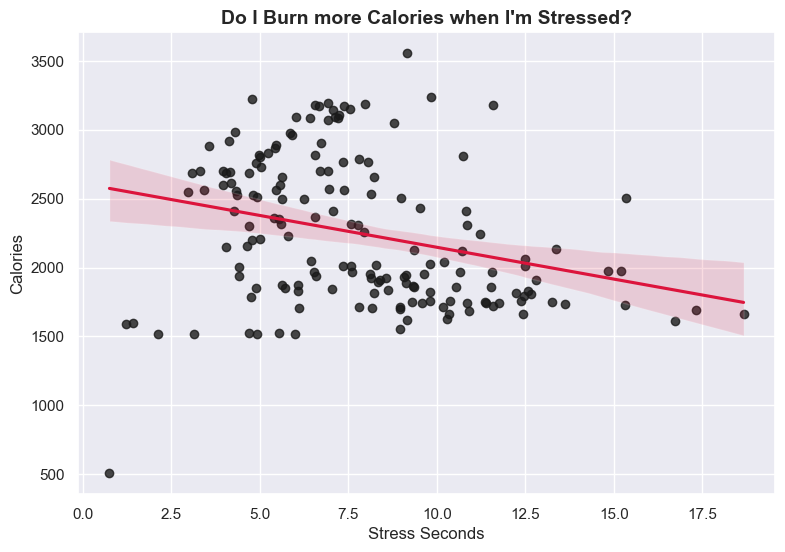

In [78]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Stress Seconds',
            y='Calories',
            data=df_viz_tmp,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': NEGATIVE_REF_COLOR},
            )
plt.title('Do I Burn more Calories when I\'m Stressed?', fontweight='bold', fontsize=14)

Text(0.5, 1.0, "Do I Burn more Calories when I'm Stressed?")

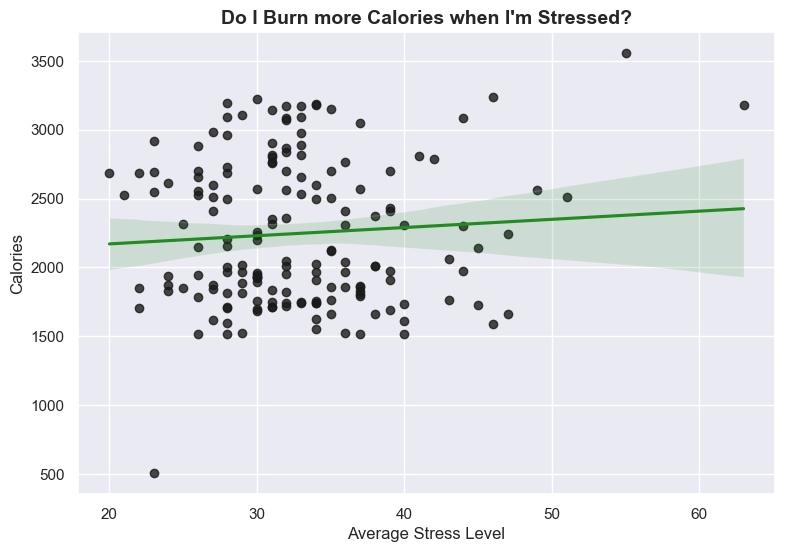

In [79]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Calories',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Do I Burn more Calories when I\'m Stressed?', fontweight='bold', fontsize=14)

In [80]:
df_viz_tmp = df_viz[['Average Stress Level', 'Active Seconds', 'Highly Active Seconds']]

Text(0.5, 1.0, 'Is there a correlation between my active seconds and stress?')

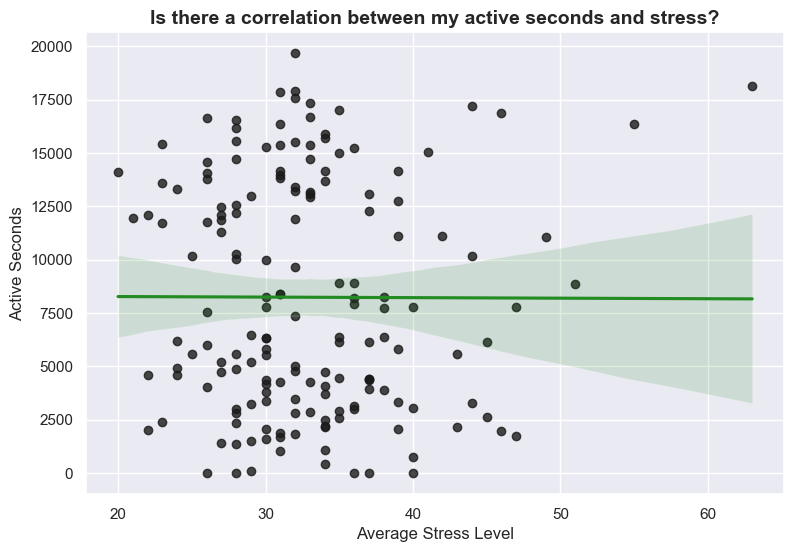

In [81]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Active Seconds',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Is there a correlation between my active seconds and stress?', fontweight='bold', fontsize=14)

Text(0.5, 1.0, 'Is there a correlation between my high active seconds and stress?')

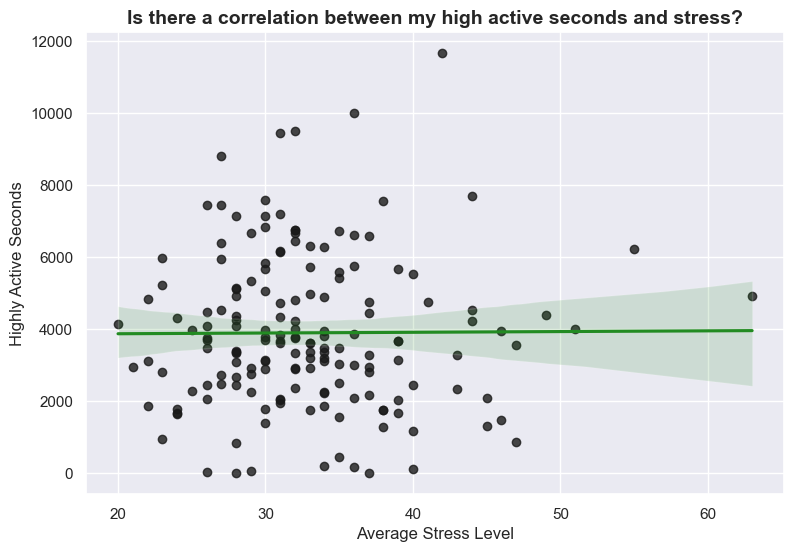

In [82]:
sns.set(rc={'figure.figsize': (9,6)})
sns.regplot(x='Average Stress Level',
            y='Highly Active Seconds',
            data=df_viz,
            # color='grey'
            scatter_kws={'color': 'k'},
            line_kws={'color': POSITIVE_REF_COLOR},
            )
plt.title('Is there a correlation between my high active seconds and stress?', fontweight='bold', fontsize=14)

In [83]:
df_viz['Sleep Start Timestamp Local'] = pd.to_datetime(df_viz['Sleep Start Timestamp Local'])
df_viz['Sleep End Timestamp Local'] = pd.to_datetime(df_viz['Sleep End Timestamp Local'])

/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/1820574455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_viz['Sleep Start Timestamp Local'] = pd.to_datetime(df_viz['Sleep Start Timestamp Local'])
/var/folders/_9/nyjys43x4nv6dxyk3y75vzh80000gn/T/ipykernel_27968/1820574455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_viz['Sleep End Timestamp Local'] = pd.to_datetime(df_viz['Sleep End Timestamp Local'])


In [84]:
df['Sleep End Timestamp Local'].dt.hour

AttributeError: Can only use .dt accessor with datetimelike values

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'CALM'),
  Text(1, 0, 'BALANCED'),
  Text(2, 0, 'BALANCED_AWAKE'),
  Text(3, 0, 'STRESSFUL'),
  Text(4, 0, 'STRESSFUL_AWAKE'),
  Text(5, 0, 'VERY_STRESSFUL'),
  Text(6, 0, 'UNKNOWN')])

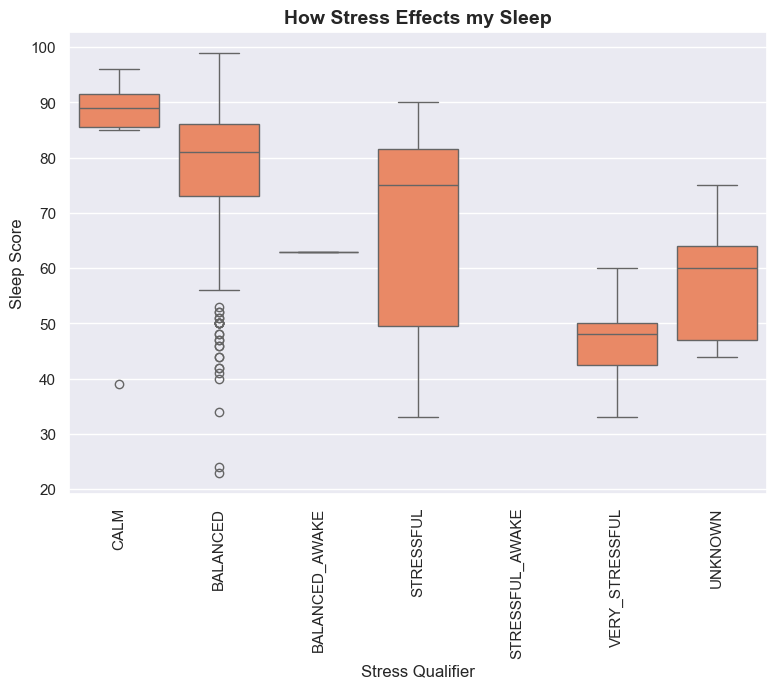

In [330]:
sns.boxplot(df_viz,
            x='Stress Qualifier',
            y='Sleep Score',
            color=MAIN_COLOR,
            order=['CALM', 'BALANCED', 'BALANCED_AWAKE', 'STRESSFUL', 'STRESSFUL_AWAKE', 'VERY_STRESSFUL', 'UNKNOWN'])
plt.title('How Stress Effects my Sleep', fontweight='bold', fontsize=14)
plt.xticks(rotation=90)

<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.tim

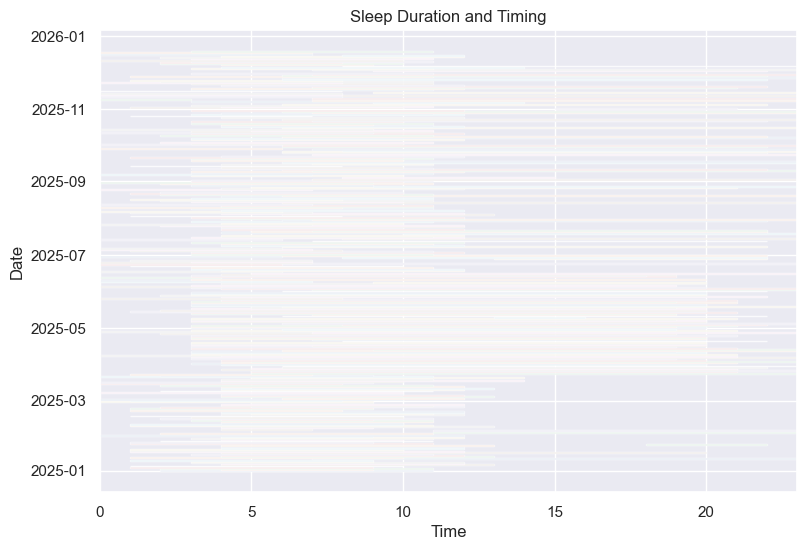

In [336]:

fig, ax = plt.subplots()

for i, row in df_viz.iterrows():
    ax.barh(
        y=row["Date"],
        width=row['Sleep End Timestamp Local'].hour - row['Sleep Start Timestamp Local'].hour,
        left=row['Sleep Start Timestamp Local'].hour,
        alpha=0.8
    )

ax.set_xlabel("Time")
ax.set_ylabel("Date")
ax.set_title("Sleep Duration and Timing")
plt.show()